**Realizado por:**

- Guadalupe Castillo Ochoa
- Kevin Santiago Restrepo Alzate
- Luis David Botero Palacio


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)   # muestra todas las columnas
pd.set_option('display.width', None)         # no corta el ancho de la línea
pd.set_option('display.max_colwidth', None)  # no trunca el contenido de cada celda


In [50]:
RUTA_ARCHIVO = "Estudiantes_cursos_procesado_enriquecido.xlsx"
df = pd.read_excel(RUTA_ARCHIVO)
df.columns = (
    df.columns.str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Integración de los datos

## Asignación de tipo de dato correcto

In [51]:

COLUMNAS_FECHA = [
    "Fecha de Nacmto",
]

for col in COLUMNAS_FECHA:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

In [52]:
COLUMNAS_ID_NUMERICAS = [
    "ID Estudiante",
    "ID_docente",
]

for col in COLUMNAS_ID_NUMERICAS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

In [53]:
COLUMNAS_NUMERICAS = [
    "# Cancelaciones totales",
    "%Cancelación",
    "Nota Curso",
    "Créditos Aprobados",
    "Créditos Inscritos Totales",
    "Créditos Cancelados",
    "Cursos Cancelados",
    "Edad",
    "Créditos Reprobados Totales",
    "Total Créditos Académicos",
    "Nota Parcial",
    "# Periodos Programa Actual",
    "Créditos Cancelados Progr. Actual",
    "Créditos Reprobados Progr. Actual",
    "Créditos Aprobados Progr. Actual",
    "Promedio Notas Parciales",
    "Créditos Académicos",
    "Promedio notas",
    "Promedio Notas Prog. Actual",
    "creditos_aprobados_hist",
    "creditos_reprobados_hist",
    "cursos_reprobados_hist",
    "cursos_tomados_hist",
    "tasa_aprobacion_hist",
    "promedio_notas_hist",
    "num_periodos_cursados",
    "tasa_aprobacion_materia_hist",
    "tasa_aprobacion_docente_hist",
    "Edad_profesor",
]

for col in COLUMNAS_NUMERICAS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

In [54]:
COLUMNAS_TEXTO_ALTA_CARDINALIDAD = [
    "Ciudad Nacimiento",
    "Nombre Estudiante",
    "Colegio origen",
    "NRC",
    "Docente Principal",
    "Materia-Curso",
    "Título Curso",
]

for col in COLUMNAS_TEXTO_ALTA_CARDINALIDAD:
    if col in df.columns:
        df[col] = df[col].astype("string")

In [55]:
COLUMNAS_CATEGORICAS = [
    "Año Saber11",
    "Período Académico",
    "Semestre",
    "Año semestre",
    "# Cancelaciones",
    "Naturaleza Colegio",
    "Cursos Reprobados",
    "Departamento Colegio",
    "Departamento Nacimiento",
    "Estrato",
    "Género",
    "Método Asistencia Curso",
    "País Nacimiento",
    "Tipo Alumno",
    "# Aprobaciones",
    "Ubicación",
    "Programa1",
    "Aprobado",
    "Escuela",
    "Género_profesor",
    "Nivel Formación",
    "Rol",
    "Tipo Empleado",
    "Vinculación",
    "Categoria_Materia",
    "Zona_Ciudad_Nacimiento",
    "Tipo_Municipio_Nacimiento",
    "Confianza_Zona",
    "Título Curso",
]

for col in COLUMNAS_CATEGORICAS:
    if col in df.columns:
        df[col] = df[col].astype("category")


In [56]:
df.sample(10)

,Año Saber11,Período Académico,Semestre,Año semestre,# Cancelaciones,# Cancelaciones totales,%Cancelación,Ciudad Nacimiento,ID Estudiante,Nombre Estudiante,Colegio origen,Nota Curso,NRC,Créditos Aprobados,Fecha de Nacmto,Créditos Inscritos Totales,Créditos Cancelados,Naturaleza Colegio,Cursos Cancelados,Cursos Reprobados,Departamento Colegio,Departamento Nacimiento,Docente Principal,Edad,Estrato,Créditos Reprobados Totales,Género,Total Créditos Académicos,Materia-Curso,Método Asistencia Curso,Nota Parcial,País Nacimiento,# Periodos Programa Actual,Créditos Cancelados Progr. Actual,Créditos Reprobados Progr. Actual,Créditos Aprobados Progr. Actual,Tipo Alumno,Título Curso,# Aprobaciones,Ubicación,Promedio Notas Parciales,Créditos Académicos,Promedio notas,Promedio Notas Prog. Actual,Programa1,Aprobado,creditos_aprobados_hist,creditos_reprobados_hist,cursos_reprobados_hist,cursos_tomados_hist,tasa_aprobacion_hist,promedio_notas_hist,num_periodos_cursados,tasa_aprobacion_materia_hist,ID_docente,tasa_aprobacion_docente_hist,Escuela,Género_profesor,Edad_profesor,Nivel Formación,Rol,Tipo Empleado,Vinculación,Categoria_Materia,Zona_Ciudad_Nacimiento,Tipo_Municipio_Nacimiento,Confianza_Zona
10331,2018.0,202420,20,2024,0,0.0,0.0,Medellín,391724,KELLY TATIANA RIVERA TREJOS,INS ED SANTA JUANA DE LESTONAC,3.94,20358,1.0,2001-05-27,1.0,0.0,OFICIAL,0.0,0,ANTIOQUIA,Antioquia-CO,MARIA ELENA MONTOYA VELEZ - 86975,23.0,2,0.0,F,1.0,6069-0059,C - Clase presencial,NaN,Colombia,8.0,0.0,0.0,1.0,C - Estudiante matriculado,PREPRÁCTICA II,1,8.0,4.021429,1.0,3.94,3.94,Negocios Internal-Med,1,122.0,8.0,3.0,58.0,0.810345,3.402069,11.0,0.950262,86975,0.913140,"Economía, Administración y Negocios",F,36.0,010-Esp. Universitaria,Sin Asignar Rol,IAD - Interno Administrativo,Externo,Práctica,Urbana,Ciudad / aglomeración,Alta
28738,2022.0,202420,20,2024,0,0.0,0.0,Medellín,519136,GERALDINE ORTEGA QUINTERO,COLEGIO CORAZONISTA,3.01,20402,2.0,2005-07-29,2.0,0.0,NO OFICIAL,0.0,0,ANTIOQUIA,Antioquia-CO,JUAN CARLOS RESTREPO RIOS - 9889,19.0,5,0.0,F,2.0,6611-0042,C - Clase presencial,NaN,Colombia,8.0,0.0,0.0,2.0,C - Estudiante matriculado,INGENIERÍA ECONÓMICA,1,3.0,2.175000,2.0,3.01,3.01,Admón de Empresas-Med,1,36.0,0.0,0.0,14.0,0.928571,3.935000,2.0,0.751157,9889,0.735642,Ciencias Sociales,M,57.0,010-Esp. Universitaria,Académico,DEF - Docente Externo de Facultad,Externo,Ciencia Básica,Urbana,Ciudad / aglomeración,Alta
3024,2022.0,202520,20,2025,0,0.0,0.0,Medellín,187435,SIMON OSORIO ALVAREZ,COLEGIO DE LA UNIVERSIDAD PONTIFICIA BOLIVARIANA,3.90,10242,2.0,2005-10-20,2.0,0.0,NO OFICIAL,0.0,0,ANTIOQUIA,Antioquia-CO,DANIEL VELASQUEZ CARTAGENA - 497959,20.0,3,0.0,M,2.0,DEPO-0004,C - Clase presencial,NaN,Colombia,8.0,0.0,0.0,2.0,C - Estudiante matriculado,FUTBOL,1,NaN,NaN,2.0,3.90,3.90,Economía - Med,1,57.0,3.0,1.0,33.0,0.515152,2.712121,4.0,0.891026,497959,0.853659,Otros,M,27.0,007-Universitaria,Académico,DEF - Docente Externo de Facultad,Externo,Electivas / Optativas,Urbana,Ciudad / aglomeración,Alta
435,2017.0,202420,20,2024,0,0.0,0.0,Medellín,132573,DANIEL MORENO GALLEGO,LICEO SAN RAFAEL,2.75,22644,0.0,2000-12-29,3.0,0.0,NO OFICIAL,0.0,1,ANTIOQUIA,Antioquia-CO,DANIEL BETANCUR TRUJILLO - 123804,24.0,Sin dato,3.0,M,3.0,9937-0059,C - Clase presencial,NaN,Colombia,8.0,0.0,3.0,0.0,C - Estudiante matriculado,OPTIMIZACIÓN,0,4.0,2.800000,3.0,2.75,2.75,Negocios Internal-Med,0,63.0,66.0,25.0,61.0,0.426230,1.826721,12.0,0.819734,123804,0.792208,"Economía, Administración y Negocios",M,34.0,012-Maestria,Académico,DEF - Docente Externo de Facultad,Externo,Ciencia Básica,Urbana,Ciudad / aglomeración,Alta
28212,2022.0,202610,10,2026,0,0.0,0.0,Andes,516354,MARIA CAMILA RESTREPO JARAMILLO,LICEO MARIA AUXILIADORA,4.95,25046,3.0,2002-09-17,3.0,0.0,OFICIAL,0.0,0,ANTIOQUIA,Antioquia-CO,ANDRES FELIPE CAÑAS URIBE - 335605,24.0,5,0.0,F,3.0,6069-0064,C - Clase presencial,NaN,Colombia,8.0,0.0,0.0,3.0,C - Estudiante matriculado,GESTIÓN LOGÍSTICA INTEGRAL,1,7.0,NaN,3.0,4.95,4.95,Admón de Empresas-Med

## Validación de datos duplicados

In [57]:
datos_iniciales = len(df)
print(f'Cantidad de datos iniciales: {datos_iniciales}')

# Se eliminan las filas exactamente iguales
df.drop_duplicates(
    inplace = True
)

# Se reinician los index para no tener huecos en ellos
df.reset_index(
    drop=True,
    inplace=True
)

datos_sin_duplicados = len(df)
print(f'Cantidad de datos al eliminar duplicados: {datos_sin_duplicados}')
print(f'Cantidad de datos eliminados por duplicados:{datos_iniciales - datos_sin_duplicados}')

Cantidad de datos iniciales: 35639
Cantidad de datos al eliminar duplicados: 35639
Cantidad de datos eliminados por duplicados:0


Se realiza validación de datos duplicados para limpeza de la base, en la cual no contamos con datos duplicados

# Eliminación de variables irrelevantes y redundantes

## Variables irrelevantes

In [58]:
df.sample(1)

,Año Saber11,Período Académico,Semestre,Año semestre,# Cancelaciones,# Cancelaciones totales,%Cancelación,Ciudad Nacimiento,ID Estudiante,Nombre Estudiante,Colegio origen,Nota Curso,NRC,Créditos Aprobados,Fecha de Nacmto,Créditos Inscritos Totales,Créditos Cancelados,Naturaleza Colegio,Cursos Cancelados,Cursos Reprobados,Departamento Colegio,Departamento Nacimiento,Docente Principal,Edad,Estrato,Créditos Reprobados Totales,Género,Total Créditos Académicos,Materia-Curso,Método Asistencia Curso,Nota Parcial,País Nacimiento,# Periodos Programa Actual,Créditos Cancelados Progr. Actual,Créditos Reprobados Progr. Actual,Créditos Aprobados Progr. Actual,Tipo Alumno,Título Curso,# Aprobaciones,Ubicación,Promedio Notas Parciales,Créditos Académicos,Promedio notas,Promedio Notas Prog. Actual,Programa1,Aprobado,creditos_aprobados_hist,creditos_reprobados_hist,cursos_reprobados_hist,cursos_tomados_hist,tasa_aprobacion_hist,promedio_notas_hist,num_periodos_cursados,tasa_aprobacion_materia_hist,ID_docente,tasa_aprobacion_docente_hist,Escuela,Género_profesor,Edad_profesor,Nivel Formación,Rol,Tipo Empleado,Vinculación,Categoria_Materia,Zona_Ciudad_Nacimiento,Tipo_Municipio_Nacimiento,Confianza_Zona
19325,2020.0,202420,20,2024,0,0.0,NaN,Medellín,459269,JUAN CAMILO OCHOA URIBE,COL PARROQUIAL SAN JUDAS TADEO,NaN,32227,0.0,2004-03-09,0.0,0.0,NO OFICIAL,0.0,0,ANTIOQUIA,Antioquia-CO,CAROLINA GAVIRIA OLARTE - 434974,20.0,3,0.0,M,0.0,6069-0057,G - Requisito de Grado,NaN,Colombia,8.0,0.0,0.0,0.0,C - Estudiante matriculado,PRÁCTICA,0,8.0,NaN,0.0,NaN,NaN,Admón de Empresas-Med,0,135.0,0.0,0.0,50.0,1.0,4.4068,7.0,0.58216,434974,0.87,"Economía, Administración y Negocios",F,35.0,007-Universitaria,Académico,DEF - Docente Externo de Facultad,Externo,Práctica,Urbana,Ciudad / aglomeración,Alta


In [59]:
COLUMNAS_IRRELEVANTES = [
    'Período Académico','Año semestre', 'Ciudad Nacimiento','ID Estudiante', 'Nombre Estudiante','Colegio origen','NRC','Docente Principal',
    'Materia-Curso','ID_docente','Título Curso'
]

# Se eliminan las columnas irrelevantes
df.drop(
    columns = COLUMNAS_IRRELEVANTES,
    inplace = True
)

df.sample(1)

,Año Saber11,Semestre,# Cancelaciones,# Cancelaciones totales,%Cancelación,Nota Curso,Créditos Aprobados,Fecha de Nacmto,Créditos Inscritos Totales,Créditos Cancelados,Naturaleza Colegio,Cursos Cancelados,Cursos Reprobados,Departamento Colegio,Departamento Nacimiento,Edad,Estrato,Créditos Reprobados Totales,Género,Total Créditos Académicos,Método Asistencia Curso,Nota Parcial,País Nacimiento,# Periodos Programa Actual,Créditos Cancelados Progr. Actual,Créditos Reprobados Progr. Actual,Créditos Aprobados Progr. Actual,Tipo Alumno,# Aprobaciones,Ubicación,Promedio Notas Parciales,Créditos Académicos,Promedio notas,Promedio Notas Prog. Actual,Programa1,Aprobado,creditos_aprobados_hist,creditos_reprobados_hist,cursos_reprobados_hist,cursos_tomados_hist,tasa_aprobacion_hist,promedio_notas_hist,num_periodos_cursados,tasa_aprobacion_materia_hist,tasa_aprobacion_docente_hist,Escuela,Género_profesor,Edad_profesor,Nivel Formación,Rol,Tipo Empleado,Vinculación,Categoria_Materia,Zona_Ciudad_Nacimiento,Tipo_Municipio_Nacimiento,Confianza_Zona
19506,2020.0,20,0,0.0,0.0,4.51,4.0,2003-11-03,4.0,0.0,OFICIAL,0.0,0,CHOCO,Chocó-CO,21.0,5,0.0,M,4.0,C - Clase presencial,NaN,Colombia,8.0,0.0,0.0,4.0,C - Estudiante matriculado,1,7.0,4.15,4.0,4.51,4.51,Negocios Internal-Med,1,113.0,0.0,0.0,45.0,1.0,4.506222,6.0,0.931759,0.965625,"Economía, Administración y Negocios",M,31.0,012-Maestria,Táctico-Estratégico,DCD - Docente Comisión Administrativ,Interno,Formación Profesional Específica,Rural,Rural,Media


Se eliminan aquellas columnas que no aportan información relevante para la predicción, ademas se eliminan variables con alta cardinalidad y con dimencionamiento jerarquico

In [60]:
COLUMNAS_DATA_LAKAGE = [
    '# Cancelaciones', '# Cancelaciones totales', '%Cancelación', 'Créditos Aprobados','Créditos Inscritos Totales', 'Créditos Cancelados',
    'Cursos Cancelados', 'Cursos Reprobados', 'Créditos Reprobados Totales','Total Créditos Académicos','Nota Parcial','Nota Parcial',
    'País Nacimiento', '# Periodos Programa Actual','Créditos Cancelados Progr. Actual','Créditos Reprobados Progr. Actual',
    'Créditos Aprobados Progr. Actual','# Aprobaciones','Promedio Notas Parciales','Promedio notas','Promedio Notas Prog. Actual'
]

# Se eliminan las columnas identificadas como data lakage
df.drop(
    columns = COLUMNAS_DATA_LAKAGE,
    inplace = True
)

df.sample(1)

,Año Saber11,Semestre,Nota Curso,Fecha de Nacmto,Naturaleza Colegio,Departamento Colegio,Departamento Nacimiento,Edad,Estrato,Género,Método Asistencia Curso,Tipo Alumno,Ubicación,Créditos Académicos,Programa1,Aprobado,creditos_aprobados_hist,creditos_reprobados_hist,cursos_reprobados_hist,cursos_tomados_hist,tasa_aprobacion_hist,promedio_notas_hist,num_periodos_cursados,tasa_aprobacion_materia_hist,tasa_aprobacion_docente_hist,Escuela,Género_profesor,Edad_profesor,Nivel Formación,Rol,Tipo Empleado,Vinculación,Categoria_Materia,Zona_Ciudad_Nacimiento,Tipo_Municipio_Nacimiento,Confianza_Zona
25195,2021.0,10,4.5,2004-11-17,NO OFICIAL,ANTIOQUIA,Antioquia-CO,19.0,2,M,C - Clase presencial,C - Estudiante matriculado,2.0,3.0,Negocios Internal-Med,1,12.0,0.0,0.0,5.0,1.0,3.834,1.0,0.956432,0.9325,"Economía, Administración y Negocios",F,54.0,013-Doctorado,Académico,DEF - Docente Externo de Facultad,Interno,Formación Profesional Específica,Urbana,Ciudad / aglomeración,Alta


Se eliminan aquellas columnas que cuyo valor no pude ser conocido si no hasta que ya pasa el hecho que se desea predecir, lo cual produce data lakage para el ejercicio de predicción

## Variables redundantes matemáticamente

In [61]:
VARIABLES_REDUNDANTES = ['Nota Curso','Fecha de Nacmto']

# Se eliminan las columnas identificadas como data lakage
df.drop(
    columns = VARIABLES_REDUNDANTES,
    inplace = True
)

df.sample(1)

,Año Saber11,Semestre,Naturaleza Colegio,Departamento Colegio,Departamento Nacimiento,Edad,Estrato,Género,Método Asistencia Curso,Tipo Alumno,Ubicación,Créditos Académicos,Programa1,Aprobado,creditos_aprobados_hist,creditos_reprobados_hist,cursos_reprobados_hist,cursos_tomados_hist,tasa_aprobacion_hist,promedio_notas_hist,num_periodos_cursados,tasa_aprobacion_materia_hist,tasa_aprobacion_docente_hist,Escuela,Género_profesor,Edad_profesor,Nivel Formación,Rol,Tipo Empleado,Vinculación,Categoria_Materia,Zona_Ciudad_Nacimiento,Tipo_Municipio_Nacimiento,Confianza_Zona
33971,2024.0,20,NO OFICIAL,ANTIOQUIA,Antioquia-CO,18.0,4,M,C - Clase presencial,C - Estudiante matriculado,1.0,2.0,Gestión del empren y la innova,1,14.0,0.0,0.0,8.0,0.75,3.2675,1.0,0.758065,1.0,Educación y Pedagogía,M,58.0,012-Maestria,Académico,DEF - Docente Externo de Facultad,Interno,Formación Humanística Institucional,Urbana,Ciudad / aglomeración,Alta


Se eliminan aquellas variables que tienen relación lineal con otras dentro del dataframe ya que una de ellas puede ser calculada a partir de la otra

# Descripción estadística de datos

## Variables numéricas

In [62]:
# Estadistica descriptiva
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,35639.0,21.085580,3.085801,16.0,19.000000,21.000000,22.000000,56.0
Créditos Académicos,35639.0,2.651926,1.309023,0.0,2.000000,3.000000,3.000000,10.0
creditos_aprobados_hist,35639.0,67.224726,39.381172,0.0,33.000000,66.000000,99.000000,213.0
creditos_reprobados_hist,35639.0,4.493308,6.847964,0.0,0.000000,2.000000,7.000000,69.0
cursos_reprobados_hist,35639.0,1.646342,2.514889,0.0,0.000000,1.000000,2.000000,26.0
cursos_tomados_hist,35639.0,31.129633,16.957549,1.0,16.000000,30.000000,44.000000,106.0
tasa_aprobacion_hist,35639.0,0.776985,0.208065,0.0,0.666667,0.833333,0.944444,1.0
promedio_notas_hist,35639.0,3.533853,0.738104,0.0,3.143208,3.644545,4.080000,5.0
num_periodos_cursados,35639.0,4.253963,3.267042,0.0,2.000000,4.000000,6.000000,21.0
tasa_aprobacion_materia_hist,35639.0,0.844346,0.124336,0.0,0.787572,0.876339,0.935484,1.0


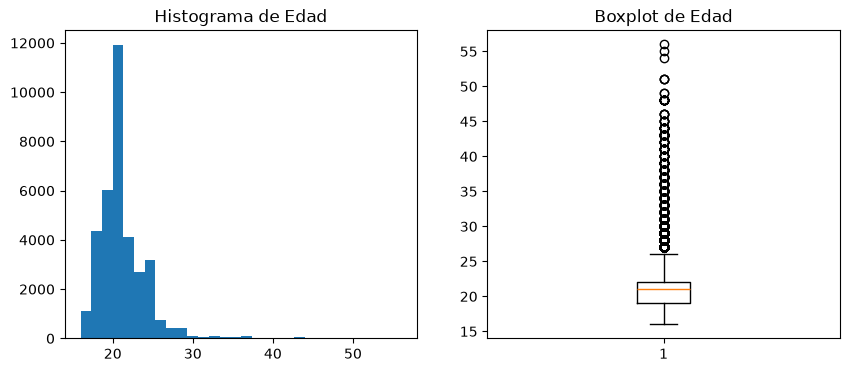

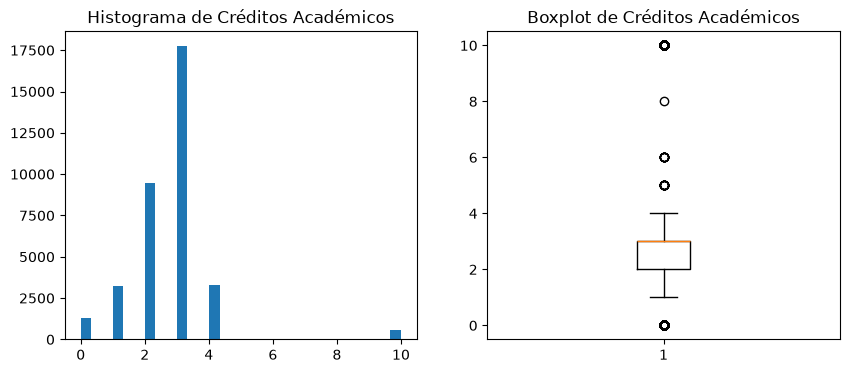

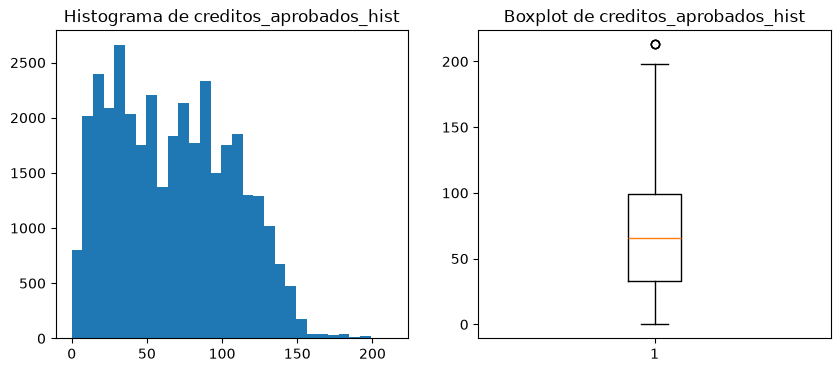

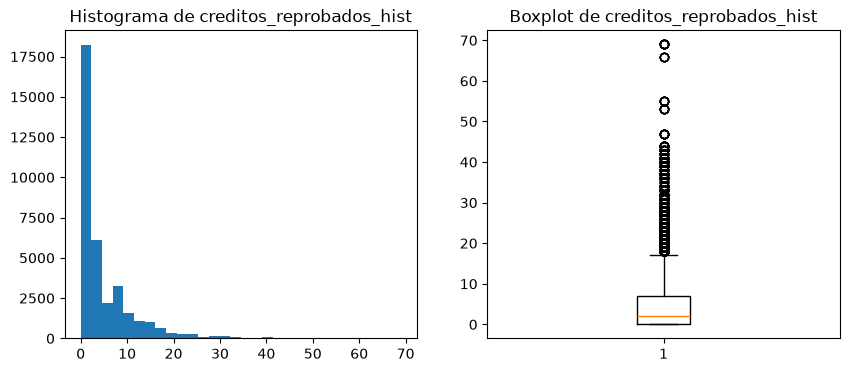

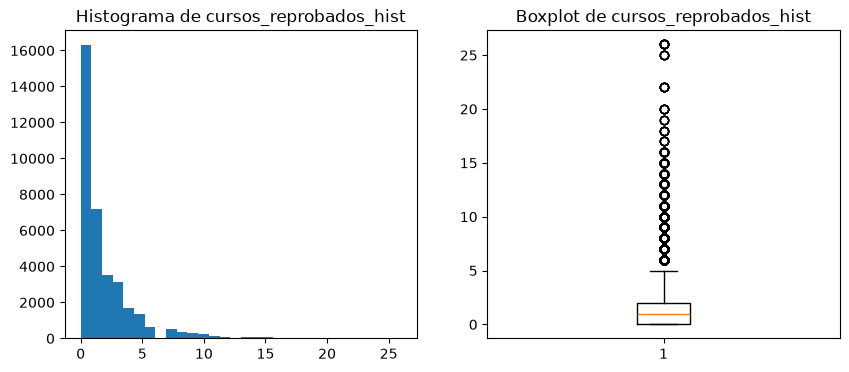

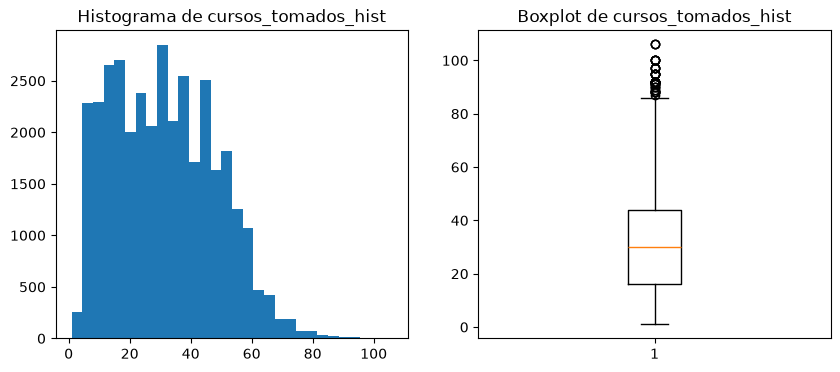

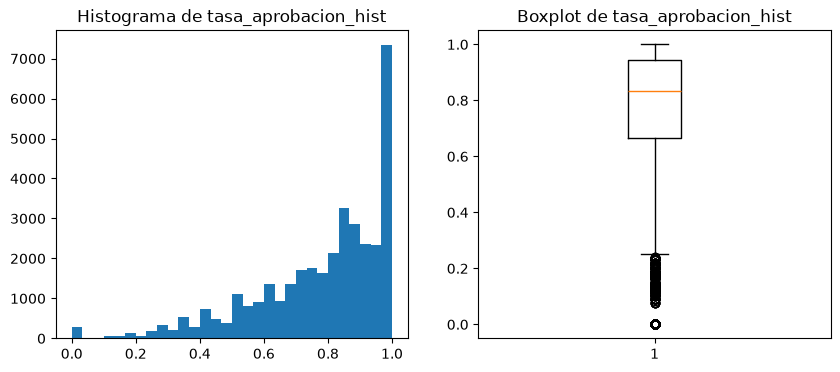

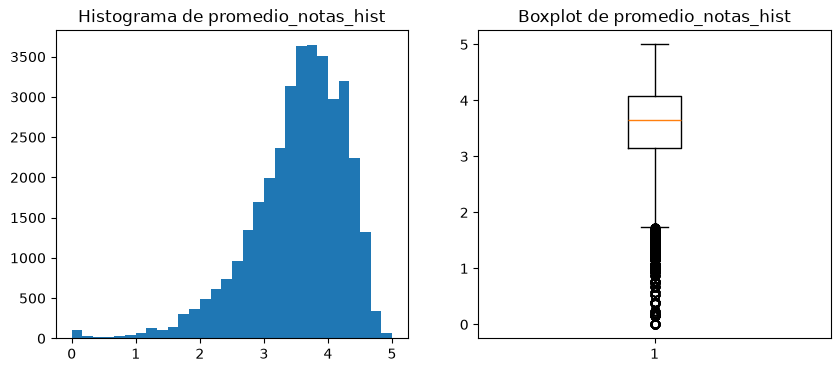

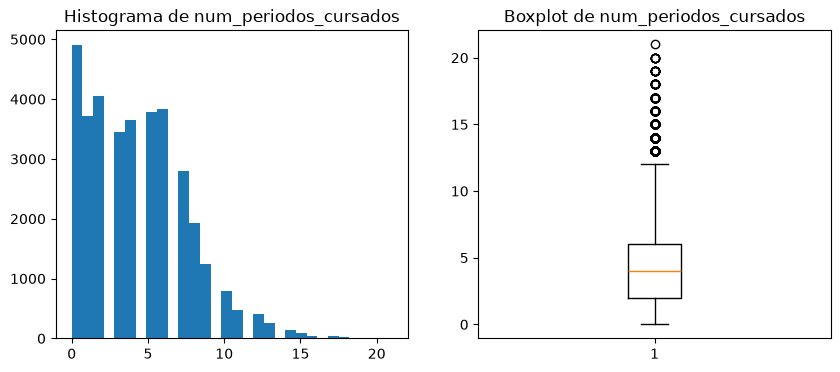

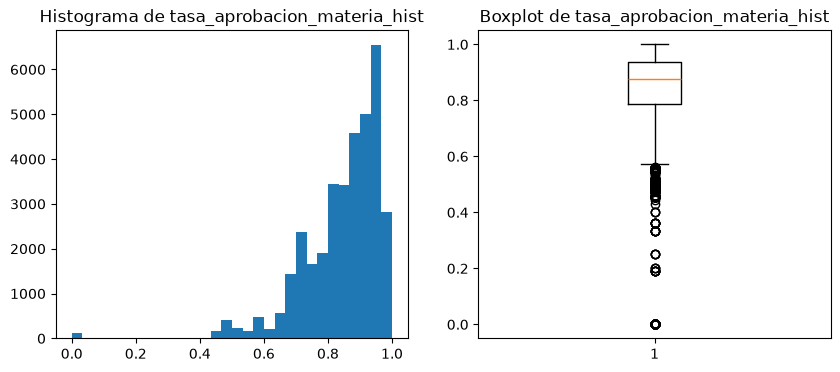

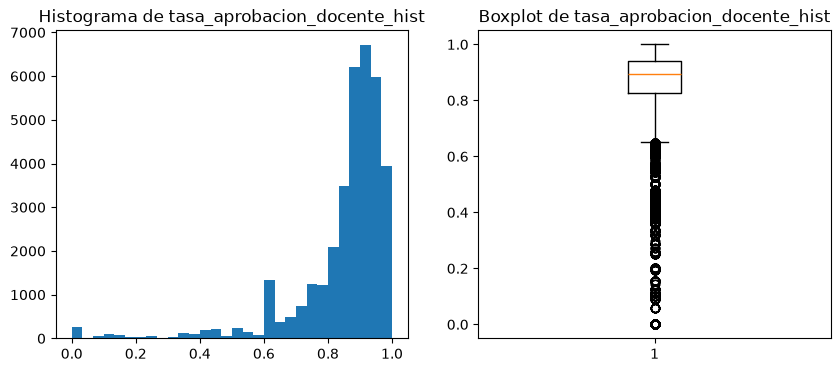

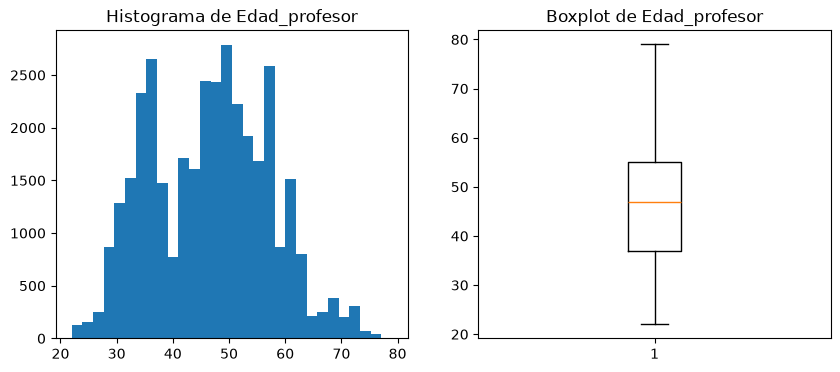

In [63]:
columnas_numericas = df.select_dtypes(include=["float64", "int64", "Int64"]).columns

for col in columnas_numericas:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.hist(df[col].dropna(), bins=30)
    ax1.set_title(f"Histograma de {col}")

    ax2.boxplot(df[col].dropna())
    ax2.set_title(f"Boxplot de {col}")

    plt.show()

## Variables categóricas

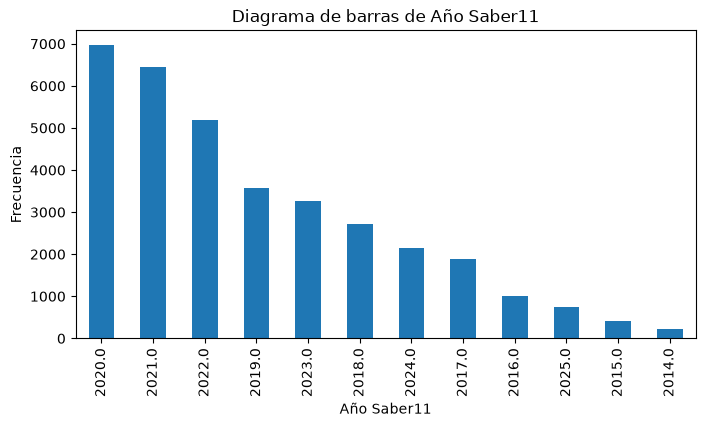

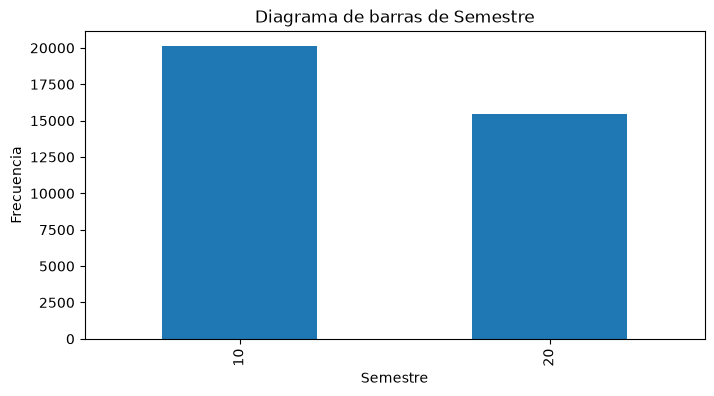

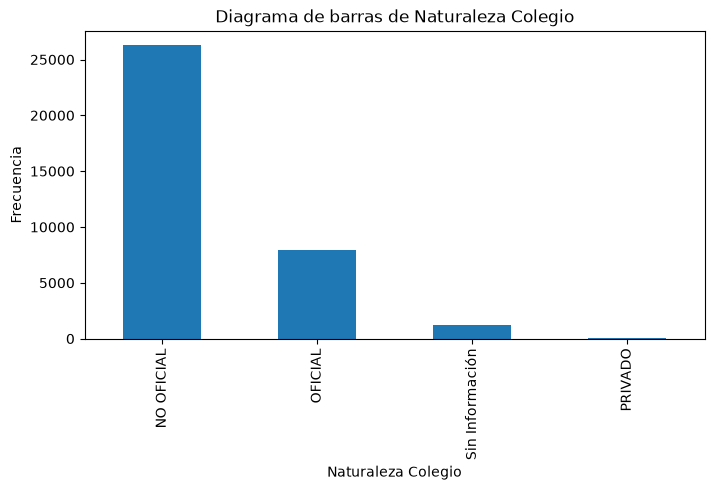

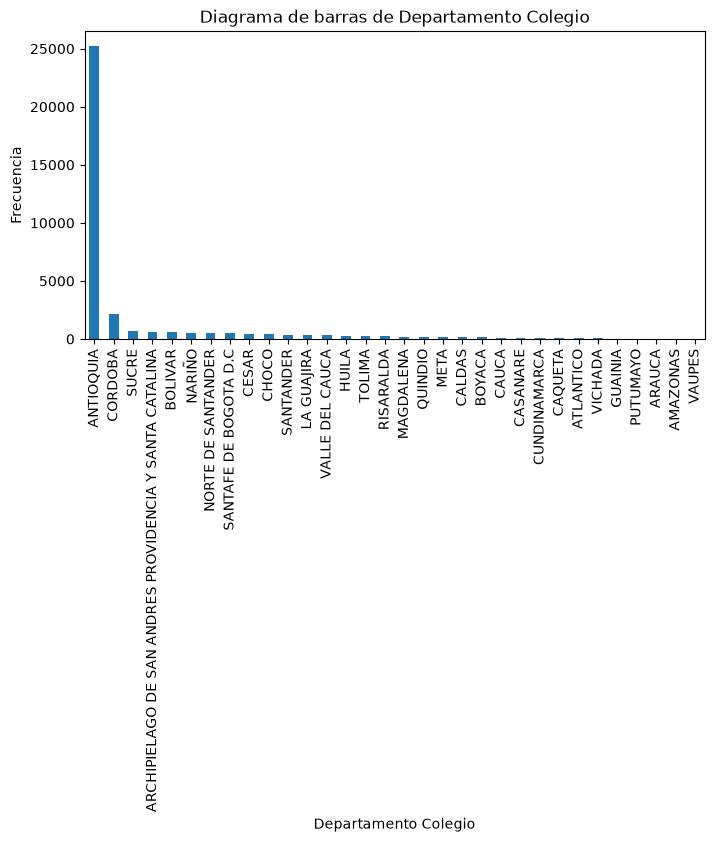

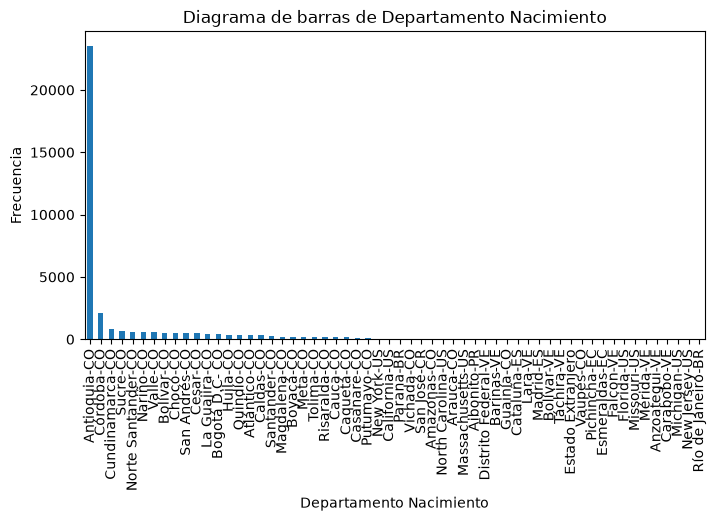

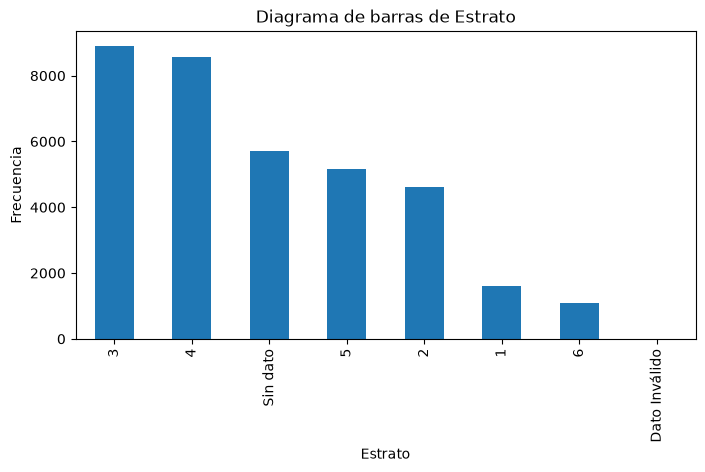

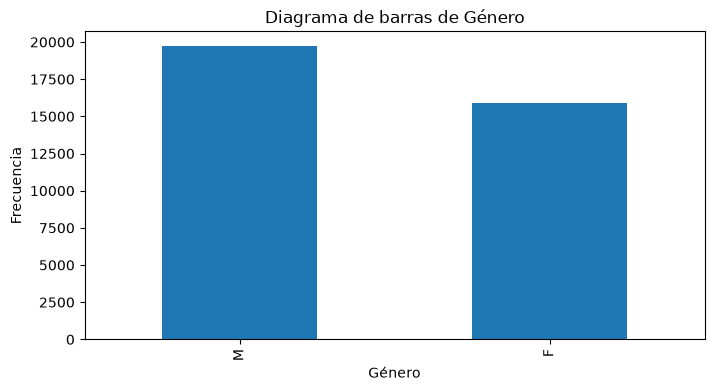

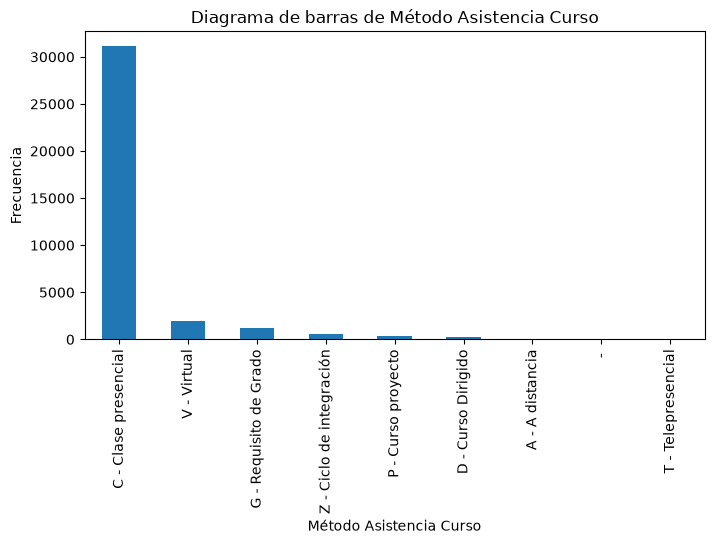

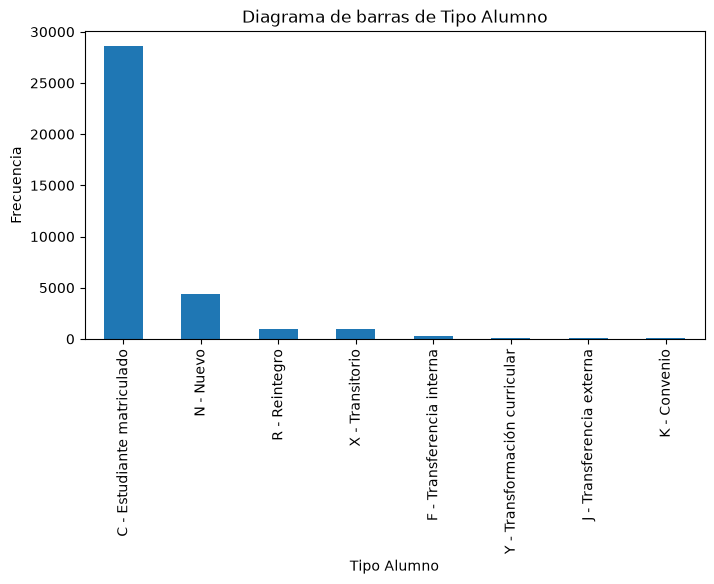

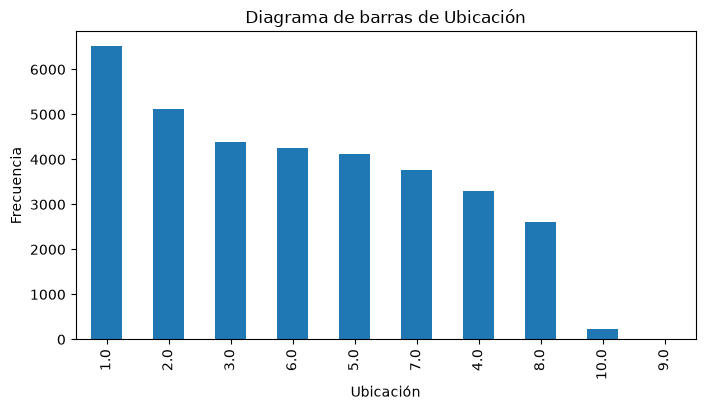

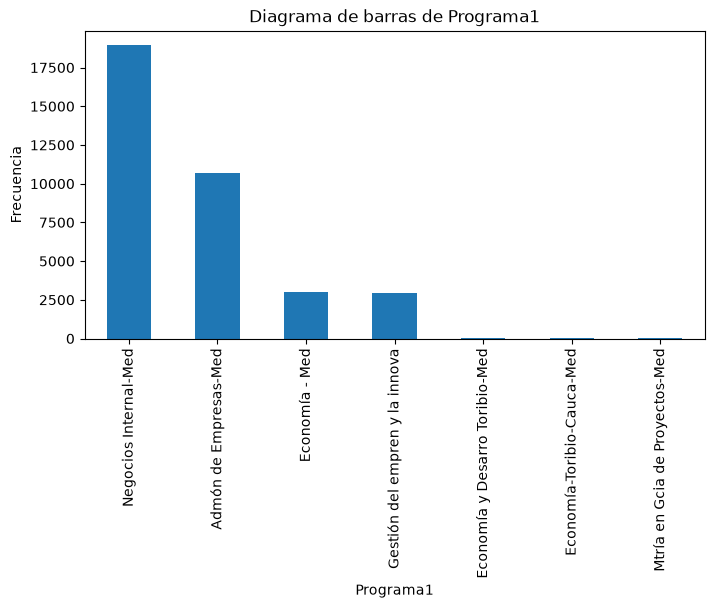

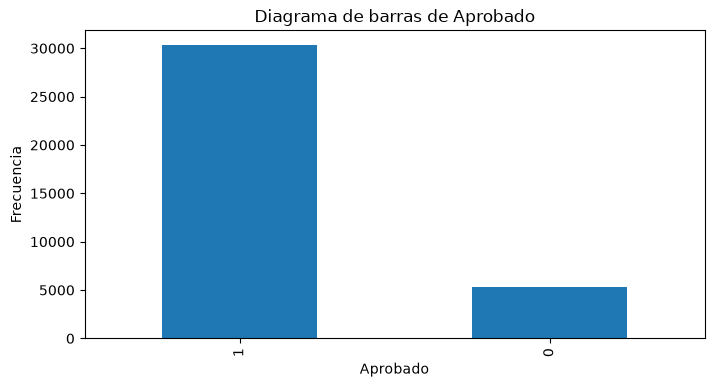

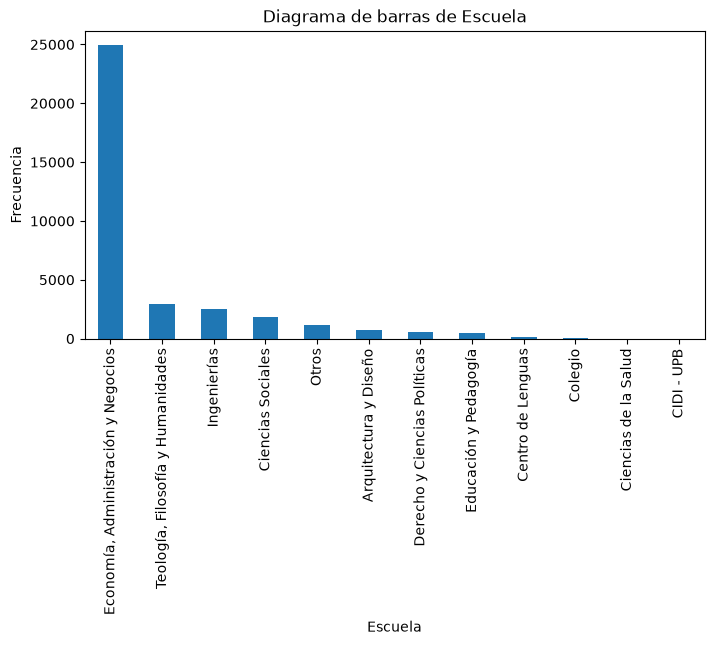

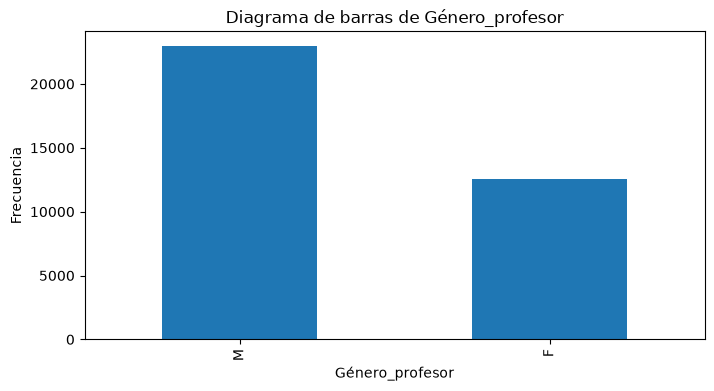

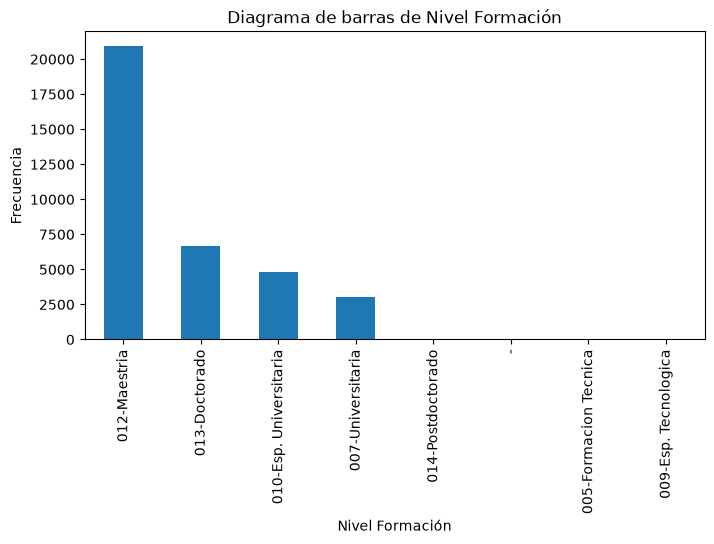

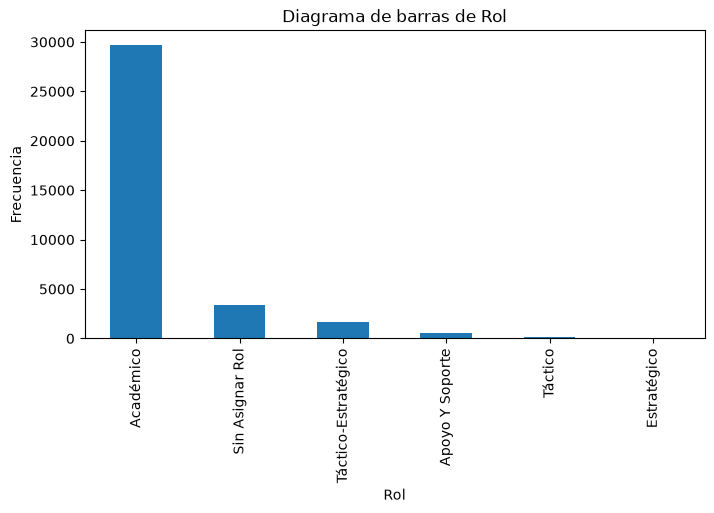

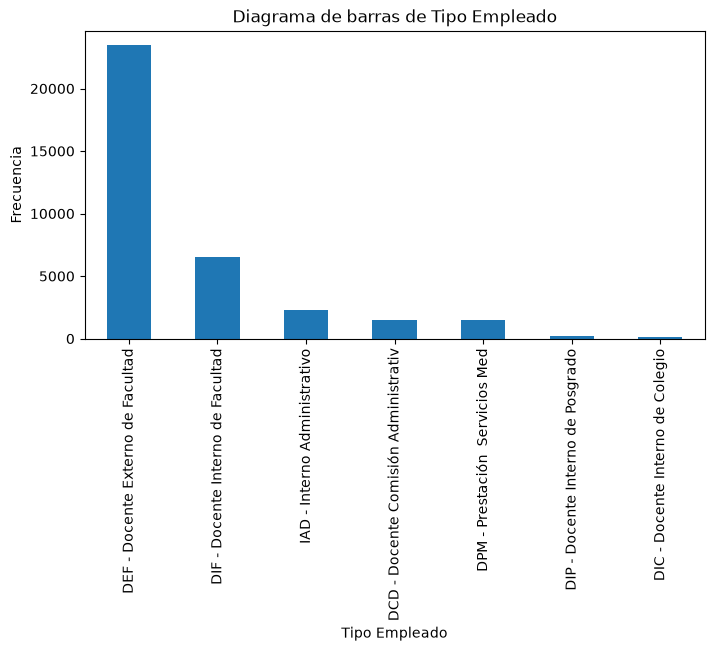

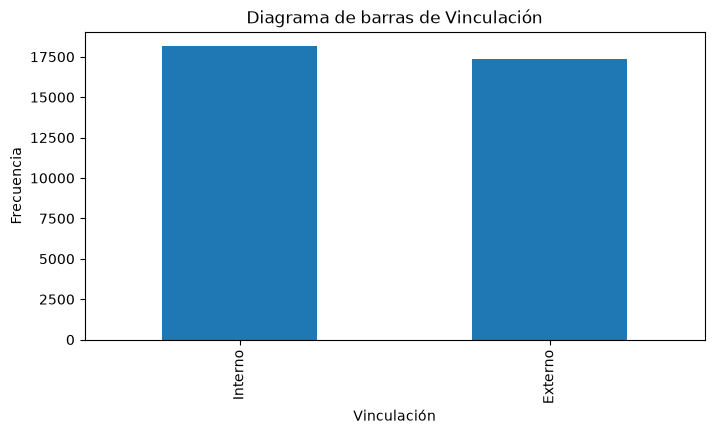

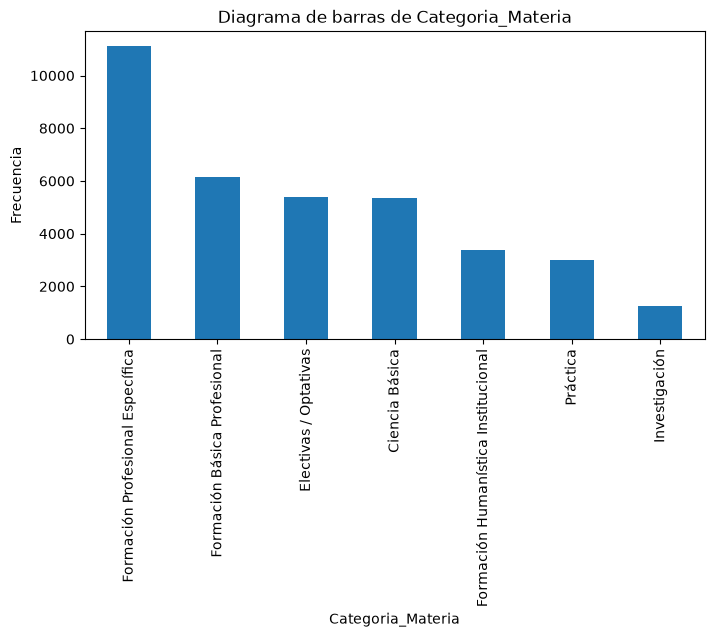

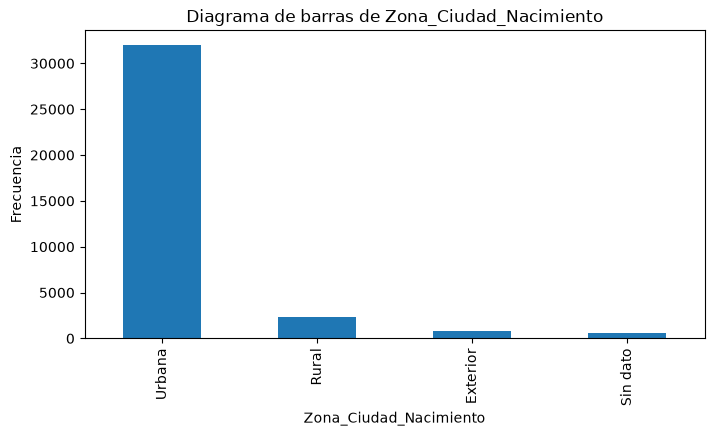

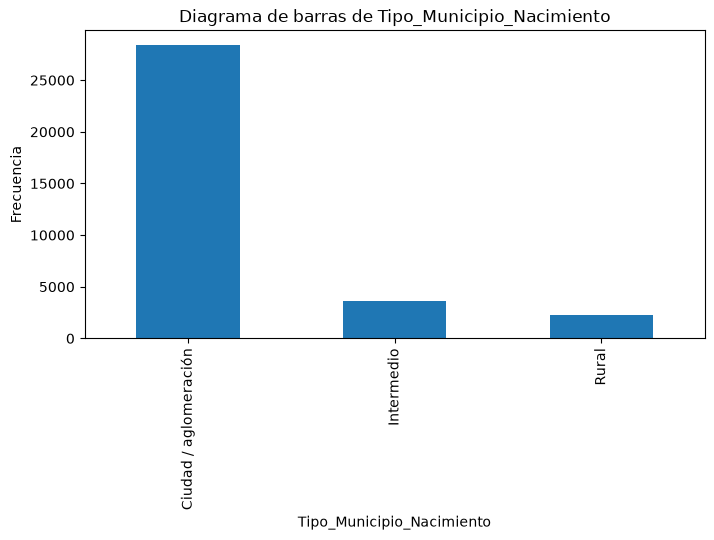

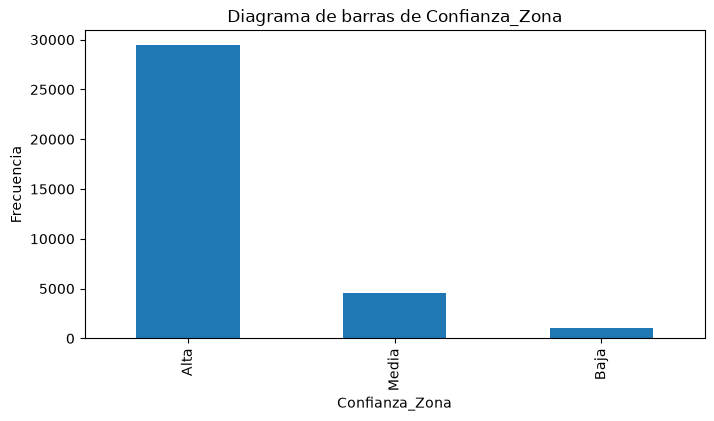

In [64]:
columnas_categoricas = df.select_dtypes(include=["category"]).columns

for col in columnas_categoricas:
    df[col].value_counts().plot(kind="bar", figsize=(8, 4))
    plt.title(f"Diagrama de barras de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

# Limpieza de datos atípicos

En este caso en las variables numericas obtenemos datos atípicos por variablilidad natural

In [65]:
print('Datos con atípicos por error humano')
print(df['Naturaleza Colegio'].value_counts())

df['Naturaleza Colegio'] = df['Naturaleza Colegio'].replace('Sin Información',np.nan)
df['Naturaleza Colegio'] = df['Naturaleza Colegio'].replace('PRIVADO','NO OFICIAL')
df['Naturaleza Colegio'] = df['Naturaleza Colegio'].cat.remove_unused_categories()

print('\nDatos corregidos')
print(df['Naturaleza Colegio'].value_counts())

Datos con atípicos por error humano
Naturaleza Colegio
NO OFICIAL         26272
OFICIAL             7980
Sin Información     1187
PRIVADO               80
Name: count, dtype: int64

Datos corregidos
Naturaleza Colegio
NO OFICIAL    26352
OFICIAL        7980
Name: count, dtype: int64


In [66]:
print('Datos con atípicos por error humano')
print(df['Estrato'].value_counts())


df['Estrato'] = df['Estrato'].replace('Dato Inválido',np.nan)
df['Estrato'] = df['Estrato'].cat.remove_unused_categories()

print('\nDatos corregidos')
print(df['Estrato'].value_counts())

Datos con atípicos por error humano
Estrato
3                8918
4                8572
Sin dato         5699
5                5150
2                4614
1                1596
6                1084
Dato Inválido       6
Name: count, dtype: int64

Datos corregidos
Estrato
3           8918
4           8572
Sin dato    5699
5           5150
2           4614
1           1596
6           1084
Name: count, dtype: int64


In [67]:
print('Datos con atípicos por error humano')
print(df['Método Asistencia Curso'].value_counts())


df['Método Asistencia Curso'] = df['Método Asistencia Curso'].replace(' - ',np.nan)
df['Método Asistencia Curso'] = df['Método Asistencia Curso'].cat.remove_unused_categories()

print('\nDatos corregidos')
print(df['Método Asistencia Curso'].value_counts())

Datos con atípicos por error humano
Método Asistencia Curso
C - Clase presencial        31144
V - Virtual                  2005
G - Requisito de Grado       1170
Z - Ciclo de integración      578
P - Curso proyecto            401
D - Curso Dirigido            259
A - A distancia                44
 -                             33
T - Telepresencial              5
Name: count, dtype: int64

Datos corregidos
Método Asistencia Curso
C - Clase presencial        31144
V - Virtual                  2005
G - Requisito de Grado       1170
Z - Ciclo de integración      578
P - Curso proyecto            401
D - Curso Dirigido            259
A - A distancia                44
T - Telepresencial              5
Name: count, dtype: int64


In [68]:
print('Datos con atípicos por error humano')
print(df['Nivel Formación'].value_counts())


df['Nivel Formación'] = df['Nivel Formación'].replace('-',np.nan)
df['Nivel Formación'] = df['Nivel Formación'].cat.remove_unused_categories()

print('\nDatos corregidos')
print(df['Nivel Formación'].value_counts())

Datos con atípicos por error humano
Nivel Formación
012-Maestria              20928
013-Doctorado              6665
010-Esp. Universitaria     4828
007-Universitaria          3027
014-Postdoctorado            45
-                             1
005-Formacion Tecnica         1
009-Esp. Tecnologica          1
Name: count, dtype: int64

Datos corregidos
Nivel Formación
012-Maestria              20928
013-Doctorado              6665
010-Esp. Universitaria     4828
007-Universitaria          3027
014-Postdoctorado            45
005-Formacion Tecnica         1
009-Esp. Tecnologica          1
Name: count, dtype: int64


In [69]:
programas_validos = [
    'Negocios Internal-Med',
    'Admón de Empresas-Med',
    'Gestión del empren y la innova',
    'Economía - Med'
]

print('Antes:', len(df))

df = df[df['Programa1'].isin(programas_validos)]

df['Programa1'] = df['Programa1'].cat.remove_unused_categories()

print('Despues:', len(df))
print(df['Programa1'].value_counts())

Antes: 35639
Despues: 35572
Programa1
Negocios Internal-Med             18946
Admón de Empresas-Med             10676
Economía - Med                     3002
Gestión del empren y la innova     2948
Name: count, dtype: int64


In [70]:
print('Datos con atípicos por error humano')
print(df['Zona_Ciudad_Nacimiento'].value_counts())


df['Zona_Ciudad_Nacimiento'] = df['Zona_Ciudad_Nacimiento'].replace('Sin dato',np.nan)
df['Zona_Ciudad_Nacimiento'] = df['Zona_Ciudad_Nacimiento'].cat.remove_unused_categories()

print('\nDatos corregidos')
print(df['Zona_Ciudad_Nacimiento'].value_counts())

Datos con atípicos por error humano
Zona_Ciudad_Nacimiento
Urbana      31991
Rural        2239
Exterior      757
Sin dato      585
Name: count, dtype: int64

Datos corregidos
Zona_Ciudad_Nacimiento
Urbana      31991
Rural        2239
Exterior      757
Name: count, dtype: int64


In [71]:
df['ORIGEN_NACIMIENTO'] = np.where(
    df['Departamento Nacimiento'] == 'Antioquia-CO',
    "local",
    'foraneo'
)

df['ORIGEN_NACIMIENTO'] = np.where(
    df['Departamento Nacimiento'].isna(),
    np.nan,
    df['ORIGEN_NACIMIENTO']
)
df['ORIGEN_NACIMIENTO'] = df['ORIGEN_NACIMIENTO'].astype('category')

<Axes: xlabel='ORIGEN_NACIMIENTO'>

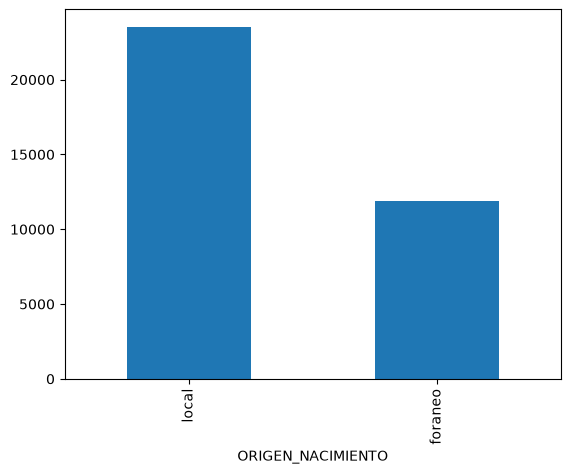

In [72]:
df['ORIGEN_NACIMIENTO'].value_counts().plot(kind='bar')

In [73]:
df['ORIGEN_COLEGIO'] = np.where(
    df['Departamento Colegio'] == 'ANTIOQUIA',
    "local",
    'foraneo'
)

df['ORIGEN_COLEGIO'] = np.where(
    df['Departamento Colegio'].isna(),
    np.nan,
    df['ORIGEN_COLEGIO']
)
df['ORIGEN_COLEGIO'] = df['ORIGEN_COLEGIO'].astype('category')

<Axes: xlabel='ORIGEN_COLEGIO'>

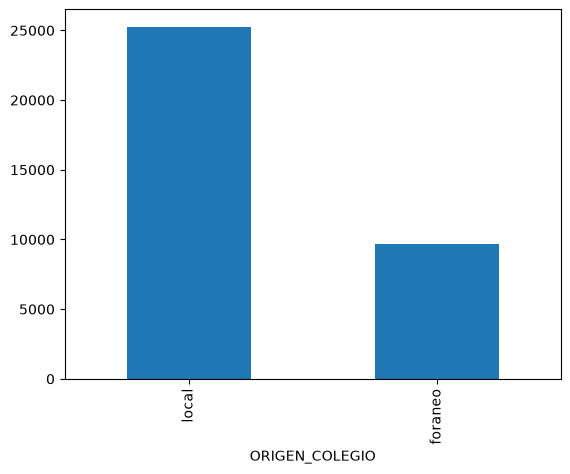

In [74]:
df['ORIGEN_COLEGIO'].value_counts().plot(kind='bar')

In [75]:
df.drop(
    columns = ['Departamento Colegio','Departamento Nacimiento'],
    inplace = True
)

In [76]:
df.info()

<class 'pandas.DataFrame'>
Index: 35572 entries, 0 to 35638
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Año Saber11                   34585 non-null  category
 1   Semestre                      35572 non-null  category
 2   Naturaleza Colegio            34267 non-null  category
 3   Edad                          35572 non-null  float64 
 4   Estrato                       35567 non-null  category
 5   Género                        35572 non-null  category
 6   Método Asistencia Curso       35539 non-null  category
 7   Tipo Alumno                   35572 non-null  category
 8   Ubicación                     34289 non-null  category
 9   Créditos Académicos           35572 non-null  float64 
 10  Programa1                     35572 non-null  category
 11  Aprobado                      35572 non-null  category
 12  creditos_aprobados_hist       35572 non-null  float64 
 13  cr

# Limpieza de datos nulos

## Eliminación de datos faltantes en la variable objetivo

In [77]:
print('Antes:', len(df))

df = df[df['Aprobado'].notna()]

print('Despues:', len(df))
print(df['Aprobado'].value_counts())

Antes: 35572
Despues: 35572
Aprobado
1    30269
0     5303
Name: count, dtype: int64


## Eliminación de filas con más del 15% de valores faltantes

In [78]:
print('Antes:', len(df))

porcentaje_nulos_fila = df.isnull().mean(axis=1)

df = df[porcentaje_nulos_fila <= 0.15]

print('Despues:', len(df))

Antes: 35572
Despues: 35427


## Variables con más del 15% de valores faltantes

In [79]:
df.isna().mean()*100

Año Saber11                     2.754961
Semestre                        0.000000
Naturaleza Colegio              3.666695
Edad                            0.000000
Estrato                         0.014114
Género                          0.000000
Método Asistencia Curso         0.081858
Tipo Alumno                     0.000000
Ubicación                       3.607418
Créditos Académicos             0.000000
Programa1                       0.000000
Aprobado                        0.000000
creditos_aprobados_hist         0.000000
creditos_reprobados_hist        0.000000
cursos_reprobados_hist          0.000000
cursos_tomados_hist             0.000000
tasa_aprobacion_hist            0.000000
promedio_notas_hist             0.000000
num_periodos_cursados           0.000000
tasa_aprobacion_materia_hist    0.000000
tasa_aprobacion_docente_hist    0.000000
Escuela                         0.000000
Género_profesor                 0.000000
Edad_profesor                   0.000000
Nivel Formación 

No contamos con variables com mas del 15% nulas

## Imputación de variables

Dado a que nuestras variables con datos nulos son categoricas se realiza la imputacion por la moda

In [80]:
df['Año Saber11'] = df['Año Saber11'].fillna(df['Año Saber11'].mode()[0])
df['Naturaleza Colegio'] = df['Naturaleza Colegio'].fillna(df['Naturaleza Colegio'].mode()[0])
df['ORIGEN_COLEGIO'] = df['ORIGEN_COLEGIO'].fillna(df['ORIGEN_COLEGIO'].mode()[0])
df['ORIGEN_NACIMIENTO'] = df['ORIGEN_NACIMIENTO'].fillna(df['ORIGEN_NACIMIENTO'].mode()[0])
df['Estrato'] = df['Estrato'].fillna(df['Estrato'].mode()[0])
df['Método Asistencia Curso'] = df['Método Asistencia Curso'].fillna(df['Método Asistencia Curso'].mode()[0])
df['Ubicación'] = df['Ubicación'].fillna(df['Ubicación'].mode()[0])
df['Nivel Formación'] = df['Nivel Formación'].fillna(df['Nivel Formación'].mode()[0])
df['Zona_Ciudad_Nacimiento'] = df['Zona_Ciudad_Nacimiento'].fillna(df['Zona_Ciudad_Nacimiento'].mode()[0])
df['Tipo_Municipio_Nacimiento'] = df['Tipo_Municipio_Nacimiento'].fillna(df['Tipo_Municipio_Nacimiento'].mode()[0])
df['Confianza_Zona'] = df['Confianza_Zona'].fillna(df['Confianza_Zona'].mode()[0])

In [81]:
df.isna().mean()*100

Año Saber11                     0.0
Semestre                        0.0
Naturaleza Colegio              0.0
Edad                            0.0
Estrato                         0.0
Género                          0.0
Método Asistencia Curso         0.0
Tipo Alumno                     0.0
Ubicación                       0.0
Créditos Académicos             0.0
Programa1                       0.0
Aprobado                        0.0
creditos_aprobados_hist         0.0
creditos_reprobados_hist        0.0
cursos_reprobados_hist          0.0
cursos_tomados_hist             0.0
tasa_aprobacion_hist            0.0
promedio_notas_hist             0.0
num_periodos_cursados           0.0
tasa_aprobacion_materia_hist    0.0
tasa_aprobacion_docente_hist    0.0
Escuela                         0.0
Género_profesor                 0.0
Edad_profesor                   0.0
Nivel Formación                 0.0
Rol                             0.0
Tipo Empleado                   0.0
Vinculación                 

# Análisis de correlaciones

In [82]:
df_corr = df.copy()

cat_cols = df_corr.select_dtypes(include=["object", "string", "category"]).columns

partes = [df_corr.drop(columns=cat_cols)]
for c in cat_cols:
    n = df_corr[c].nunique(dropna=True)
    partes.append(pd.get_dummies(df_corr[c], prefix=c, drop_first=(n == 2), dtype=int))

df_final = pd.concat(partes, axis=1)
matriz_correlacion = df_final.astype("float64").corr()
matriz_correlacion

,Edad,Créditos Académicos,creditos_aprobados_hist,creditos_reprobados_hist,cursos_reprobados_hist,cursos_tomados_hist,tasa_aprobacion_hist,promedio_notas_hist,num_periodos_cursados,tasa_aprobacion_materia_hist,tasa_aprobacion_docente_hist,Edad_profesor,Año Saber11_2014.0,Año Saber11_2015.0,Año Saber11_2016.0,Año Saber11_2017.0,Año Saber11_2018.0,Año Saber11_2019.0,Año Saber11_2020.0,Año Saber11_2021.0,Año Saber11_2022.0,Año Saber11_2023.0,Año Saber11_2024.0,Año Saber11_2025.0,Semestre_20,Naturaleza Colegio_OFICIAL,Estrato_1,Estrato_2,Estrato_3,Estrato_4,Estrato_5,Estrato_6,Estrato_Sin dato,Género_M,Método Asistencia Curso_A - A distancia,Método Asistencia Curso_C - Clase presencial,Método Asistencia Curso_D - Curso Dirigido,Método Asistencia Curso_G - Requisito de Grado,Método Asistencia Curso_P - Curso proyecto,Método Asistencia Curso_T - Telepresencial,Método Asistencia Curso_V - Virtual,Método Asistencia Curso_Z - Ciclo de integración,Tipo Alumno_C - Estudiante matriculado,Tipo Alumno_F - Transferencia interna,Tipo Alumno_J - Transferencia externa,Tipo Alumno_K - Convenio,Tipo Alumno_N - Nuevo,Tipo Alumno_R - Reintegro,Tipo Alumno_X - Transitorio,Tipo Alumno_Y - Transformación curricular,Ubicación_1.0,Ubicación_2.0,Ubicación_3.0,Ubicación_4.0,Ubicación_5.0,Ubicación_6.0,Ubicación_7.0,Ubicación_8.0,Ubicación_9.0,Ubicación_10.0,Programa1_Admón de Empresas-Med,Programa1_Economía - Med,Programa1_Gestión del empren y la innova,Programa1_Negocios Internal-Med,Aprobado_1,Escuela_Arquitectura y Diseño,Escuela_CIDI - UPB,Escuela_Centro de Lenguas,Escuela_Ciencias Sociales,Escuela_Ciencias de la Salud,Escuela_Colegio,Escuela_Derecho y Ciencias Políticas,"Escuela_Economía, Administración y Negocios",Escuela_Educación y Pedagogía,Escuela_Ingenierías,Escuela_Otros,"Escuela_Teología, Filosofía y Humanidades",Género_profesor_M,Nivel Formación_005-Formacion Tecnica,Nivel Formación_007-Universitaria,Nivel Formación_009-Esp. Tecnologica,Nivel Formación_010-Esp. Universitaria,Nivel Formación_012-Maestria,Nivel Formación_013-Doctorado,Nivel Formación_014-Postdoctorado,Rol_Académico,Rol_Apoyo Y Soporte,Rol_Estratégico,Rol_Sin Asignar Rol,Rol_Táctico,Rol_Táctico-Estratégico,Tipo Empleado_DCD - Docente Comisión Administrativ,Tipo Empleado_DEF - Docente Externo de Facultad,Tipo Empleado_DIC - Docente Interno de Colegio,Tipo Empleado_DIF - Docente Interno de Facultad,Tipo Empleado_DIP - Docente Interno de Posgrado,Tipo Empleado_DPM - Prestación Servicios Med,Tipo Empleado_IAD - Interno Administrativo,Vinculación_Interno,Categoria_Materia_Ciencia Básica,Categoria_Materia_Electivas / Optativas,Categoria_Materia_Formación Básica Profesional,Categoria_Materia_Formación Humanística Institucional,Categoria_Materia_Formación Profesional Específica,Categoria_Materia_Investigación,Categoria_Materia_Práctica,Zona_Ciudad_Nacimiento_Exterior,Zona_Ciudad_Nacimiento_Rural,Zona_Ciudad_Nacimiento_Urbana,Tipo_Municipio_Nacimiento_Ciudad / aglomeración,Tipo_Municipio_Nacimiento_Intermedio,Tipo_Municipio_Nacimiento_Rural,Confianza_Zona_Alta,Confianza_Zona_Baja,Confianza_Zona_Media,ORIGEN_NACIMIENTO_local,ORIGEN_COLEGIO_local
Edad,1.000000,0.053606,0.347516,0.216055,0.240783,0.380448,0.119976,0.005094,0.618419,0.102244,0.042603,-0.029622,0.168290,0.163890,0.218361,0.173275,0.152418,0.066817,0.121989,-0.130999,-0.145143,-0.178817,-0.191173,-0.124933,-0.058737,0.018379,0.002213,-0.072925,-0.063125,-0.016098,0.025707,0.055929,0.108555,0.102243,NaN,-0.190853,0.109536,0.156547,0.046543,-0.008857,0.054183,0.068312,0.173523,-0.031091,0.001436,-0.020097,-0.289737,0.170221,0.013911,0.022177,-0.300700,-0.202741,-0.073898,0.001966,0.075637,0.154708,0.205965,0.267106,0.014619,0.154978,0.141773,0.031995,-0.004523,-0.145587,-0.042951,0.032347,0.003413,0.013236,-0.015213,-0.003503,0.002185,-0.009530,0.006523,-0.056658,-0.032013,0.025417,0.023912,0.016498,-0.001854,0.008580,-0.003610,-0.011249,0.027103,-0.029716,-0.006684,-0.111161,0.030882,0.010150,0.082037,-0.005061,0.062311,0.0586

In [83]:
matriz_correlacion.to_excel('correlaciones.xlsx',index = True)

Variables con |correlación| >= 0.8: 9


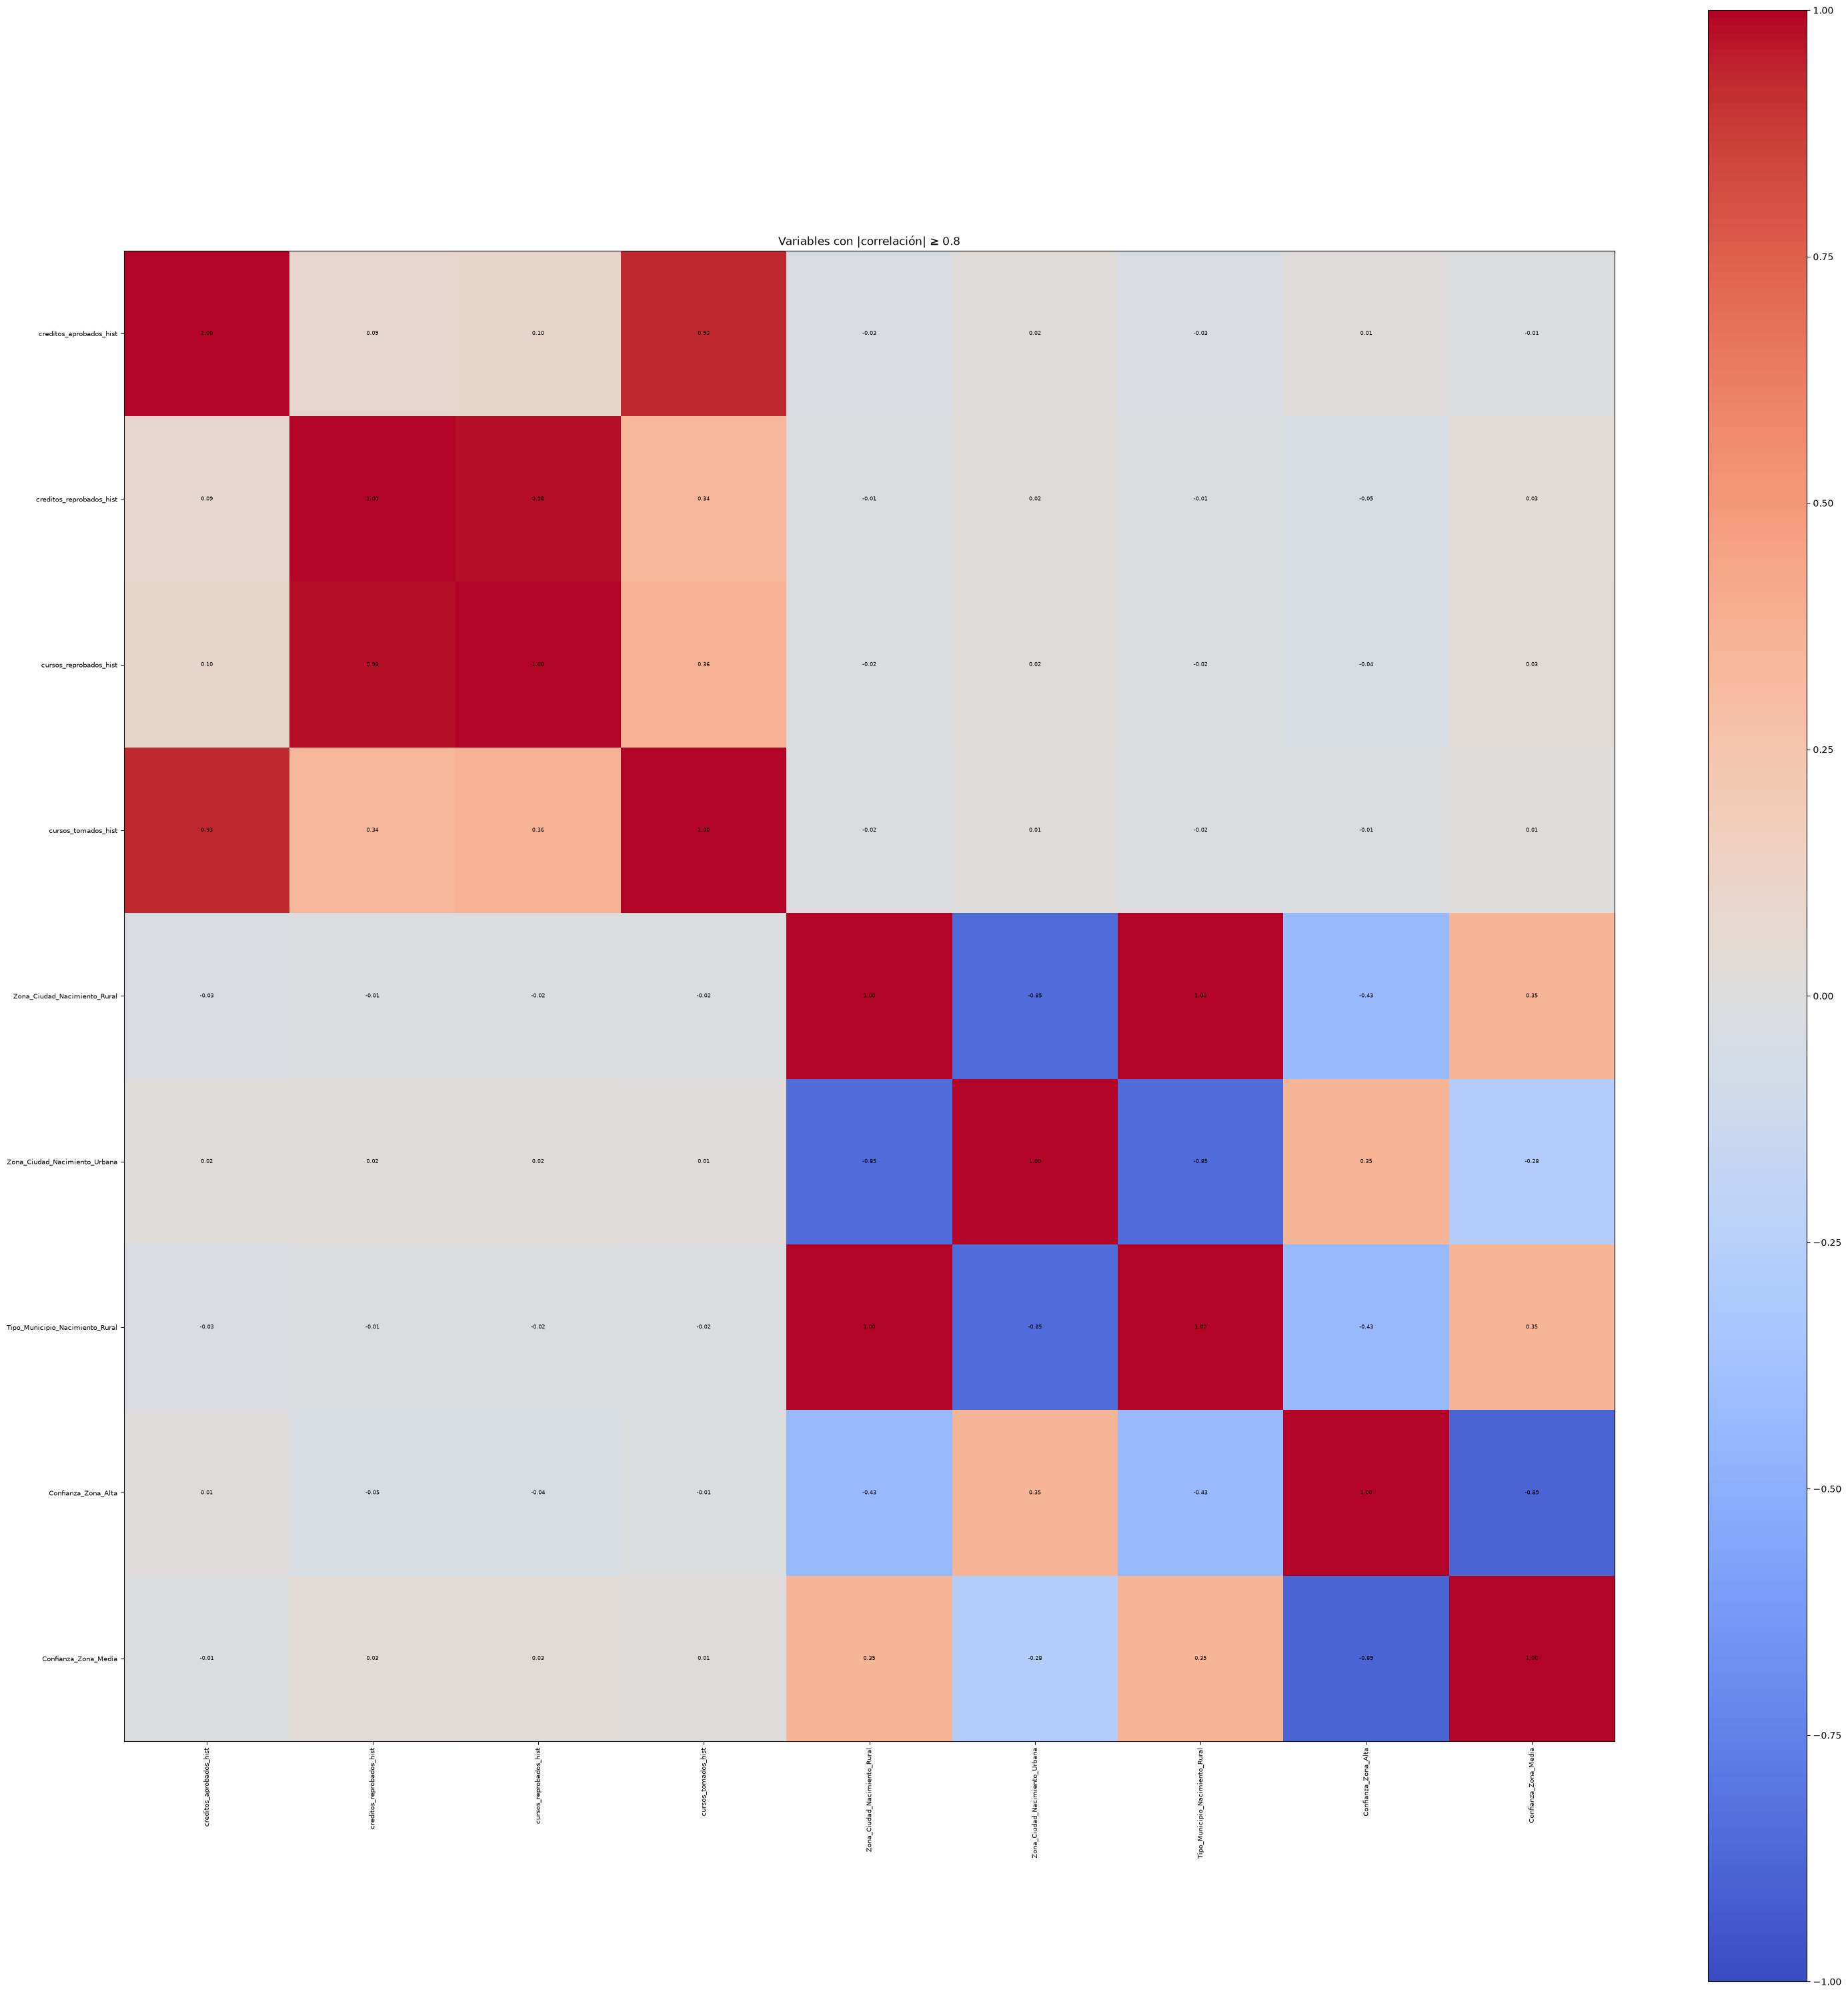

In [84]:
umbral = 0.8

matriz_correlacion = matriz_correlacion.dropna(how="all").dropna(axis=1, how="all")

mask_diag = np.eye(len(matriz_correlacion), dtype=bool)
corr_abs = matriz_correlacion.abs().mask(mask_diag)

cols_relevantes = corr_abs.columns[(corr_abs >= umbral).any()]
sub = matriz_correlacion.loc[cols_relevantes, cols_relevantes]

k = len(sub)
print(f"Variables con |correlación| >= {umbral}: {k}")

plt.figure(figsize=(30,30))
plt.imshow(sub, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(k), sub.columns, rotation=90, fontsize=7)
plt.yticks(range(k), sub.columns, fontsize=7)

if k <= 40:
    for i in range(k):
        for j in range(k):
            plt.text(j, i, f"{sub.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6)

plt.title(f"Variables con |correlación| ≥ {umbral}")
plt.tight_layout()
plt.show()

Al analizar la matriz de correlación de las variables numéricas históricas, se identificaron dos pares de variables con correlación muy alta (superior a 0.8): creditos_reprobados_hist con cursos_reprobados_hist (0.98) y creditos_aprobados_hist con cursos_tomados_hist (0.93), además de un tercer par en el límite entre tasa_aprobacion_hist y promedio_notas_hist (0.80). Esta alta correlación es esperable, ya que dentro de cada par ambas variables capturan esencialmente el mismo fenómeno académico del estudiante (créditos reprobados y cursos reprobados, o créditos aprobados y cursos tomados) medido en unidades distintas, lo que genera redundancia de información.

# Ingeniería de características

In [85]:

df_descriptiva = df.copy()

## Descriptivo

In [86]:
df_descriptiva.info()

<class 'pandas.DataFrame'>
Index: 35427 entries, 0 to 35638
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Año Saber11                   35427 non-null  category
 1   Semestre                      35427 non-null  category
 2   Naturaleza Colegio            35427 non-null  category
 3   Edad                          35427 non-null  float64 
 4   Estrato                       35427 non-null  category
 5   Género                        35427 non-null  category
 6   Método Asistencia Curso       35427 non-null  category
 7   Tipo Alumno                   35427 non-null  category
 8   Ubicación                     35427 non-null  category
 9   Créditos Académicos           35427 non-null  float64 
 10  Programa1                     35427 non-null  category
 11  Aprobado                      35427 non-null  category
 12  creditos_aprobados_hist       35427 non-null  float64 
 13  cr

A diferencia del dataset predictivo, para los objetivos descriptivos del proyecto se toma la decision de eliminar algunas variables por su baja utilidad a la hora de encontrar asociaciones relacionadas con la aprobacion o no del curso. Ademas partiendo del analisis de correlaciones algunas variables como cursos tomados y reprobados aumentan el conjunto de reglas sin mayor peso descriptivo y otras variables como las del profesor ya son representadas por variables mas significativas. Frente a esto se decide eliminar las sigueitnes:

In [87]:
VARIABLES_BAJA_UTILIDAD =[
    'Año Saber11','Confianza_Zona','num_periodos_cursados','Semestre','cursos_tomados_hist',
    'cursos_reprobados_hist','Rol','Vinculación',
]

df_descriptiva.drop(
    columns = VARIABLES_BAJA_UTILIDAD,
    inplace = True
)

In [88]:
df_descriptiva.info()

<class 'pandas.DataFrame'>
Index: 35427 entries, 0 to 35638
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Naturaleza Colegio            35427 non-null  category
 1   Edad                          35427 non-null  float64 
 2   Estrato                       35427 non-null  category
 3   Género                        35427 non-null  category
 4   Método Asistencia Curso       35427 non-null  category
 5   Tipo Alumno                   35427 non-null  category
 6   Ubicación                     35427 non-null  category
 7   Créditos Académicos           35427 non-null  float64 
 8   Programa1                     35427 non-null  category
 9   Aprobado                      35427 non-null  category
 10  creditos_aprobados_hist       35427 non-null  float64 
 11  creditos_reprobados_hist      35427 non-null  float64 
 12  tasa_aprobacion_hist          35427 non-null  float64 
 13  pr

In [89]:
df_descriptiva_cat = df_descriptiva.copy()

### Métodos categoricos

In [90]:
import pandas as pd
import numpy as np

df_apriori = df_descriptiva_cat.copy()

# 1. EDAD ESTUDIANTE
df_apriori['Edad'] = pd.cut(
    df_apriori['Edad'],
    bins=[-0.001, 19, 23, float('inf')],
    labels=['Edad_Estud: Temprana (<=19)', 'Edad_Estud: Regular (20-23)', 'Edad_Estud: Mayor (>23)']
)

# 2. CRÉDITOS ACADÉMICOS (MATRÍCULA ACTUAL)
# Distribución real: 0-2 (13,853 reg), 3 (17,727 reg), >=4 (3,847 reg)
df_apriori['Créditos Académicos'] = pd.cut(
    df_apriori['Créditos Académicos'],
    bins=[-0.001, 2, 3, float('inf')],
    labels=['Cred_Actuales: Bajos (0-2)', 'Cred_Actuales: Estándar (3)', 'Cred_Actuales: Altos (>=4)']
)

# 3. CRÉDITOS APROBADOS HISTÓRICOS (Terciles de la carrera)
df_apriori['creditos_aprobados_hist'] = pd.cut(
    df_apriori['creditos_aprobados_hist'],
    bins=[-0.001, 35, 90, float('inf')],
    labels=['Cred_Aprob: Inicial (<=35)', 'Cred_Aprob: Intermedio (36-90)', 'Cred_Aprob: Avanzado (>90)']
)

# 4. CRÉDITOS REPROBADOS HISTÓRICOS
df_apriori['creditos_reprobados_hist'] = pd.cut(
    df_apriori['creditos_reprobados_hist'],
    bins=[-0.001, 0, 4, float('inf')],
    labels=['Reprobados: Ninguno (0)', 'Reprobados: Pocos (1-4)', 'Reprobados: Muchos (>4)']
)

# 5. EDAD DEL PROFESOR
# Distribución real: <=37 (~10,000 reg), 38-49 (~13,000 reg), >=50 (~12,000 reg)
df_apriori['Edad_profesor'] = pd.cut(
    df_apriori['Edad_profesor'],
    bins=[-0.001, 37, 49, float('inf')],
    labels=['Edad_Prof: Joven (<=37)', 'Edad_Prof: Intermedio (38-49)', 'Edad_Prof: Senior (>=50)']
)

# 6. VARIABLES CONTINUAS (Tasas y Promedios)
cols_continuas = [
    'tasa_aprobacion_hist',
    'promedio_notas_hist',
    'tasa_aprobacion_materia_hist',
    'tasa_aprobacion_docente_hist'
]

for col in cols_continuas:
    prefix = col.replace('_hist', '').replace('tasa_aprobacion_', 'tasa_')

    df_apriori[col] = pd.qcut(
        df_apriori[col],
        q=3,
        labels=[f'{prefix}: Bajo', f'{prefix}: Medio', f'{prefix}: Alto'],
        duplicates='drop'
    )

# ==========================================
# VERIFICACIÓN DE REPARTO COMPLETO
# ==========================================
todas_las_columnas = [
    'Edad', 'Créditos Académicos', 'creditos_aprobados_hist',
    'creditos_reprobados_hist', 'tasa_aprobacion_hist',
    'promedio_notas_hist', 'tasa_aprobacion_materia_hist',
    'tasa_aprobacion_docente_hist', 'Edad_profesor'
]

for col in todas_las_columnas:
    print(f"=== {col} ===")
    print(df_apriori[col].value_counts(dropna=False).sort_index(), '\n')

=== Edad ===
Edad
Edad_Estud: Temprana (<=19)    11471
Edad_Estud: Regular (20-23)    18651
Edad_Estud: Mayor (>23)         5305
Name: count, dtype: int64 

=== Créditos Académicos ===
Créditos Académicos
Cred_Actuales: Bajos (0-2)     13853
Cred_Actuales: Estándar (3)    17727
Cred_Actuales: Altos (>=4)      3847
Name: count, dtype: int64 

=== creditos_aprobados_hist ===
creditos_aprobados_hist
Cred_Aprob: Inicial (<=35)         9943
Cred_Aprob: Intermedio (36-90)    14723
Cred_Aprob: Avanzado (>90)        10761
Name: count, dtype: int64 

=== creditos_reprobados_hist ===
creditos_reprobados_hist
Reprobados: Ninguno (0)    16912
Reprobados: Pocos (1-4)     7263
Reprobados: Muchos (>4)    11252
Name: count, dtype: int64 

=== tasa_aprobacion_hist ===
tasa_aprobacion_hist
tasa_aprobacion: Bajo     11814
tasa_aprobacion: Medio    11913
tasa_aprobacion: Alto     11700
Name: count, dtype: int64 

=== promedio_notas_hist ===
promedio_notas_hist
promedio_notas: Bajo     11814
promedio_notas

# Apriori

In [91]:
df_apriori.info()

<class 'pandas.DataFrame'>
Index: 35427 entries, 0 to 35638
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Naturaleza Colegio            35427 non-null  category
 1   Edad                          35427 non-null  category
 2   Estrato                       35427 non-null  category
 3   Género                        35427 non-null  category
 4   Método Asistencia Curso       35427 non-null  category
 5   Tipo Alumno                   35427 non-null  category
 6   Ubicación                     35427 non-null  category
 7   Créditos Académicos           35427 non-null  category
 8   Programa1                     35427 non-null  category
 9   Aprobado                      35427 non-null  category
 10  creditos_aprobados_hist       35427 non-null  category
 11  creditos_reprobados_hist      35427 non-null  category
 12  tasa_aprobacion_hist          35427 non-null  category
 13  pr

In [92]:
df_apriori.sample(5)

,Naturaleza Colegio,Edad,Estrato,Género,Método Asistencia Curso,Tipo Alumno,Ubicación,Créditos Académicos,Programa1,Aprobado,creditos_aprobados_hist,creditos_reprobados_hist,tasa_aprobacion_hist,promedio_notas_hist,tasa_aprobacion_materia_hist,tasa_aprobacion_docente_hist,Escuela,Género_profesor,Edad_profesor,Nivel Formación,Tipo Empleado,Categoria_Materia,Zona_Ciudad_Nacimiento,Tipo_Municipio_Nacimiento,ORIGEN_NACIMIENTO,ORIGEN_COLEGIO
27275,NO OFICIAL,Edad_Estud: Temprana (<=19),5,F,C - Clase presencial,C - Estudiante matriculado,1.0,Cred_Actuales: Bajos (0-2),Admón de Empresas-Med,1,Cred_Aprob: Intermedio (36-90),Reprobados: Ninguno (0),tasa_aprobacion: Bajo,promedio_notas: Bajo,tasa_materia: Bajo,tasa_docente: Alto,"Economía, Administración y Negocios",F,Edad_Prof: Senior (>=50),013-Doctorado,DIF - Docente Interno de Facultad,Práctica,Urbana,Ciudad / aglomeración,local,local
32117,NO OFICIAL,Edad_Estud: Temprana (<=19),5,F,C - Clase presencial,C - Estudiante matriculado,2.0,Cred_Actuales: Bajos (0-2),Negocios Internal-Med,1,Cred_Aprob: Inicial (<=35),Reprobados: Pocos (1-4),tasa_aprobacion: Bajo,promedio_notas: Bajo,tasa_materia: Medio,tasa_docente: Bajo,Derecho y Ciencias Políticas,M,Edad_Prof: Senior (>=50),013-Doctorado,DEF - Docente Externo de Facultad,Formación Profesional Específica,Urbana,Ciudad / aglomeración,foraneo,local
3030,NO OFICIAL,Edad_Estud: Regular (20-23),3,M,C - Clase presencial,K - Convenio,1.0,Cred_Actuales: Estándar (3),Economía - Med,1,Cred_Aprob: Intermedio (36-90),Reprobados: Pocos (1-4),tasa_aprobacion: Bajo,promedio_notas: Bajo,tasa_materia: Medio,tasa_docente: Bajo,"Economía, Administración y Negocios",M,Edad_Prof: Intermedio (38-49),012-Maestria,DEF - Docente Externo de Facultad,Formación Profesional Específica,Urbana,Ciudad / aglomeración,local,local
33482,OFICIAL,Edad_Estud: Temprana (<=19),3,M,C - Clase presencial,C - Estudiante matriculado,1.0,Cred_Actuales: Altos (>=4),Negocios Internal-Med,0,Cred_Aprob: Inicial (<=35),Reprobados: Pocos (1-4),tasa_aprobacion: Medio,promedio_notas: Alto,tasa_materia: Bajo,tasa_docente: Alto,Ingenierías,M,Edad_Prof: Senior (>=50),012-Maestria,DEF - Docente Externo de Facultad,Ciencia Básica,Urbana,Ciudad / aglomeración,local,local
28870,NO OFICIAL,Edad_Estud: Temprana (<=19),5,F,C - Clase presencial,N - Nuevo,1.0,Cred_Actuales: Altos (>=4),Gestión del empren y la innova,1,Cred_Aprob: Avanzado (>90),Reprobados: Ninguno (0),tasa_aprobacion: Alto,promedio_notas: Alto,tasa_materia: Bajo,tasa_docente: Bajo,"Economía, Administración y Negocios",F,Edad_Prof: Joven (<=37),010-Esp. Universitaria,DEF - Docente Externo de Facultad,Ciencia Básica,Urbana,Ciudad / aglomeración,foraneo,local


Realizando una primera evaluacion del metodo de apriori con los registros de aprobacion y repobracion se encuentra que el modelo solo es capaz con el soporte y la confianza establecidos de 0.5 encontrar asociaciones con la clase de aprueba. Por ende para el objetivo del proyecto que es encontrar co-ocurrencias y asociaciones de quienes no aprueban, se eliminan los registros de la calse aprueba

In [93]:
#df_apriori[df_apriori['Aprobado']==0]
df_apriori = df_apriori[df_apriori['Aprobado'] != 1]

In [94]:
df_apriori.info()

<class 'pandas.DataFrame'>
Index: 5284 entries, 4 to 35638
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Naturaleza Colegio            5284 non-null   category
 1   Edad                          5284 non-null   category
 2   Estrato                       5284 non-null   category
 3   Género                        5284 non-null   category
 4   Método Asistencia Curso       5284 non-null   category
 5   Tipo Alumno                   5284 non-null   category
 6   Ubicación                     5284 non-null   category
 7   Créditos Académicos           5284 non-null   category
 8   Programa1                     5284 non-null   category
 9   Aprobado                      5284 non-null   category
 10  creditos_aprobados_hist       5284 non-null   category
 11  creditos_reprobados_hist      5284 non-null   category
 12  tasa_aprobacion_hist          5284 non-null   category
 13  pro

In [95]:
from apyori import apriori

# 1. Quitar la variable objetivo (constante en este grupo)
df_reprobados = df_apriori.drop(columns=['Aprobado'])

# 2. Construir transacciones (sin valores faltantes)
transacciones = [
    [f"{col}={val}" for col, val in fila.items() if pd.notna(val)]
    for _, fila in df_reprobados.iterrows()
]

# 3. Aplicar Apriori
resultado = list(apriori(
    transacciones,
    min_support=0.50,
    min_confidence=0.50
))
print(f"Se encontraron {len(resultado)} itemsets frecuentes.")

# 4. Salida original de apyori, sin desglosar (una fila por itemset)
df_resultado = pd.DataFrame(resultado)

# 5. Perfil: características individuales más frecuentes
perfil = pd.DataFrame(
    [{'caracteristica': list(r.items)[0], 'soporte': r.support}
     for r in resultado if len(r.items) == 1]
).sort_values('soporte', ascending=False)

# 6. Desglosar cada itemset en sus reglas
filas = []
for itemset in resultado:
    for st in itemset.ordered_statistics:
        if not st.items_base:          # omite reglas sin antecedente
            continue
        filas.append({
            'itemset': itemset.items,                  # frozenset original
            'regla': f"{set(st.items_base)} → {set(st.items_add)}",
            'items_base': st.items_base,               # antecedente como sale de apyori
            'items_add': st.items_add,                 # consecuente como sale de apyori
            'antecedente': ', '.join(sorted(st.items_base)),
            'consecuente': ', '.join(sorted(st.items_add)),
            'n_items': len(st.items_base),
            'n_consecuente': len(st.items_add),
            'soporte': itemset.support,
            'confianza': st.confidence,
            'lift': st.lift,
        })

df_reglas = pd.DataFrame(filas).sort_values('lift', ascending=False).reset_index(drop=True)
print(f"Se generaron {len(df_reglas)} reglas.")

df_reglas.to_excel('apriori.xlsx',index = False)


Se encontraron 96 itemsets frecuentes.
Se generaron 296 reglas.
